In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [70]:
data = pd.read_csv('C:\\Users\\NGUYENTRAM\\Downloads\\cleaned_file.csv')
data.head()

,id,brand,price,destination,hand_luggage,checked_baggage,start_hour,end_hour,trip_mins,is_holiday,days_left
0,PQC0002,Bamboo Airways,1245267,Phú Quốc (PQC)\nSân bay Phú Quốc,7,0,Evening,Evening,60,2,1
1,PQC0323,Vietravel Airlines,1224930,Phú Quốc (PQC)\nSân bay Phú Quốc,7,0,Evening,Evening,60,2,1
2,PQC0292,Vietnam Airlines,1535463,Phú Quốc (PQC)\nSân bay Phú Quốc,12,23,Evening,Evening,60,2,1
3,PQC0109,VietJet Air,1567000,Phú Quốc (PQC)\nSân bay Phú Quốc,7,0,Afternoon,Evening,60,2,1
4,PQC0132,VietJet Air,1567000,Phú Quốc (PQC)\nSân bay Phú Quốc,7,0,Evening,Evening,65,2,1


In [71]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46628 entries, 0 to 46627
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               46628 non-null  object
 1   brand            46628 non-null  object
 2   price            46628 non-null  int64 
 3   destination      46628 non-null  object
 4   hand_luggage     46628 non-null  int64 
 5   checked_baggage  46628 non-null  int64 
 6   start_hour       46628 non-null  object
 7   end_hour         46628 non-null  object
 8   trip_mins        46628 non-null  int64 
 9   is_holiday       46628 non-null  int64 
 10  days_left        46628 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 3.9+ MB


In [72]:
data = data[~(data['days_left'] == 0)]

# EDA

In [73]:
data.describe()

,price,hand_luggage,checked_baggage,trip_mins,is_holiday,days_left
count,4.654900e+04,46549.000000,46549.000000,46549.000000,46549.000000,46549.000000
mean,2.066625e+06,9.219532,10.357022,99.895594,0.985864,10.535694
std,7.058187e+05,2.460549,11.413462,28.300063,0.986337,5.935772
min,6.902700e+05,7.000000,0.000000,45.000000,0.000000,1.000000
25%,1.592995e+06,7.000000,0.000000,80.000000,0.000000,6.000000
50%,1.945053e+06,7.000000,0.000000,115.000000,1.000000,10.000000
75%,2.436792e+06,12.000000,23.000000,125.000000,2.000000,15.000000
max,6.217970e+06,12.000000,23.000000,145.000000,3.000000,34.000000


In [74]:
data[['price','trip_mins','hand_luggage', 'checked_baggage','is_holiday','days_left']].corr().T
# data[['price','hand_luggage', 'checked_baggage','is_holiday','days_left']].corr().T

,price,trip_mins,hand_luggage,checked_baggage,is_holiday,days_left
price,1.000000,0.638637,0.234485,0.303908,0.330780,-0.080941
trip_mins,0.638637,1.000000,-0.106102,-0.065423,0.007924,-0.013652
hand_luggage,0.234485,-0.106102,1.000000,0.953567,-0.004511,0.010405
checked_baggage,0.303908,-0.065423,0.953567,1.000000,0.023982,-0.011791
is_holiday,0.330780,0.007924,-0.004511,0.023982,1.000000,0.056852
days_left,-0.080941,-0.013652,0.010405,-0.011791,0.056852,1.000000


In [75]:
data['brand'].unique()

array(['Bamboo Airways', 'Vietravel Airlines', 'Vietnam Airlines',
       'VietJet Air'], dtype=object)

In [76]:
data = pd.get_dummies(data, columns=['start_hour', 'end_hour', 'hand_luggage', 'checked_baggage'])

In [77]:
# Split data based on brand
Bamboo = data[data['brand'] == 'Bamboo Airways']
Vietjet = data[data['brand'] == 'VietJet Air']
Vietnam = data[data['brand'] == 'Vietnam Airlines']
Vietravel = data[data['brand'] == 'Vietravel Airlines']

**BAMBOO**

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

def lineplot(data):
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 15))
    axes = axes.flatten()

    i = 0
    for des in data['destination'].unique():
        print(f'Destination: {des}, count: {len(data[data["destination"] == des])}')
        df = data[data['destination'] == des]
        sns.lineplot(ax=axes[i], x='days_left', y='price', data=df, color='blue')
        axes[i].set_title(f'{df["brand"].unique()[0]} - {des}')
        axes[i].set_xlabel('Days Left')
        axes[i].set_ylabel('Price')
        i += 1

    # Ẩn các subplot còn thừa nếu có
    for j in range(i, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


Destination: Phú Quốc (PQC)
Sân bay Phú Quốc, count: 242
Destination: Đà Nẵng (DAD)
Sân bay Đà Nẵng, count: 581
Destination: Hà Nội (HAN)
Sân bay Nội Bài, count: 1883
Destination: Hải Phòng (HPH)
Sân bay quốc tế Cát Bi, count: 201
Destination: Đà Lạt (DLI)
Sân bay Liên Khương, count: 225


) missing from font(s) DejaVu Sans.emp\ipykernel_18120\2195073531.py:22: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


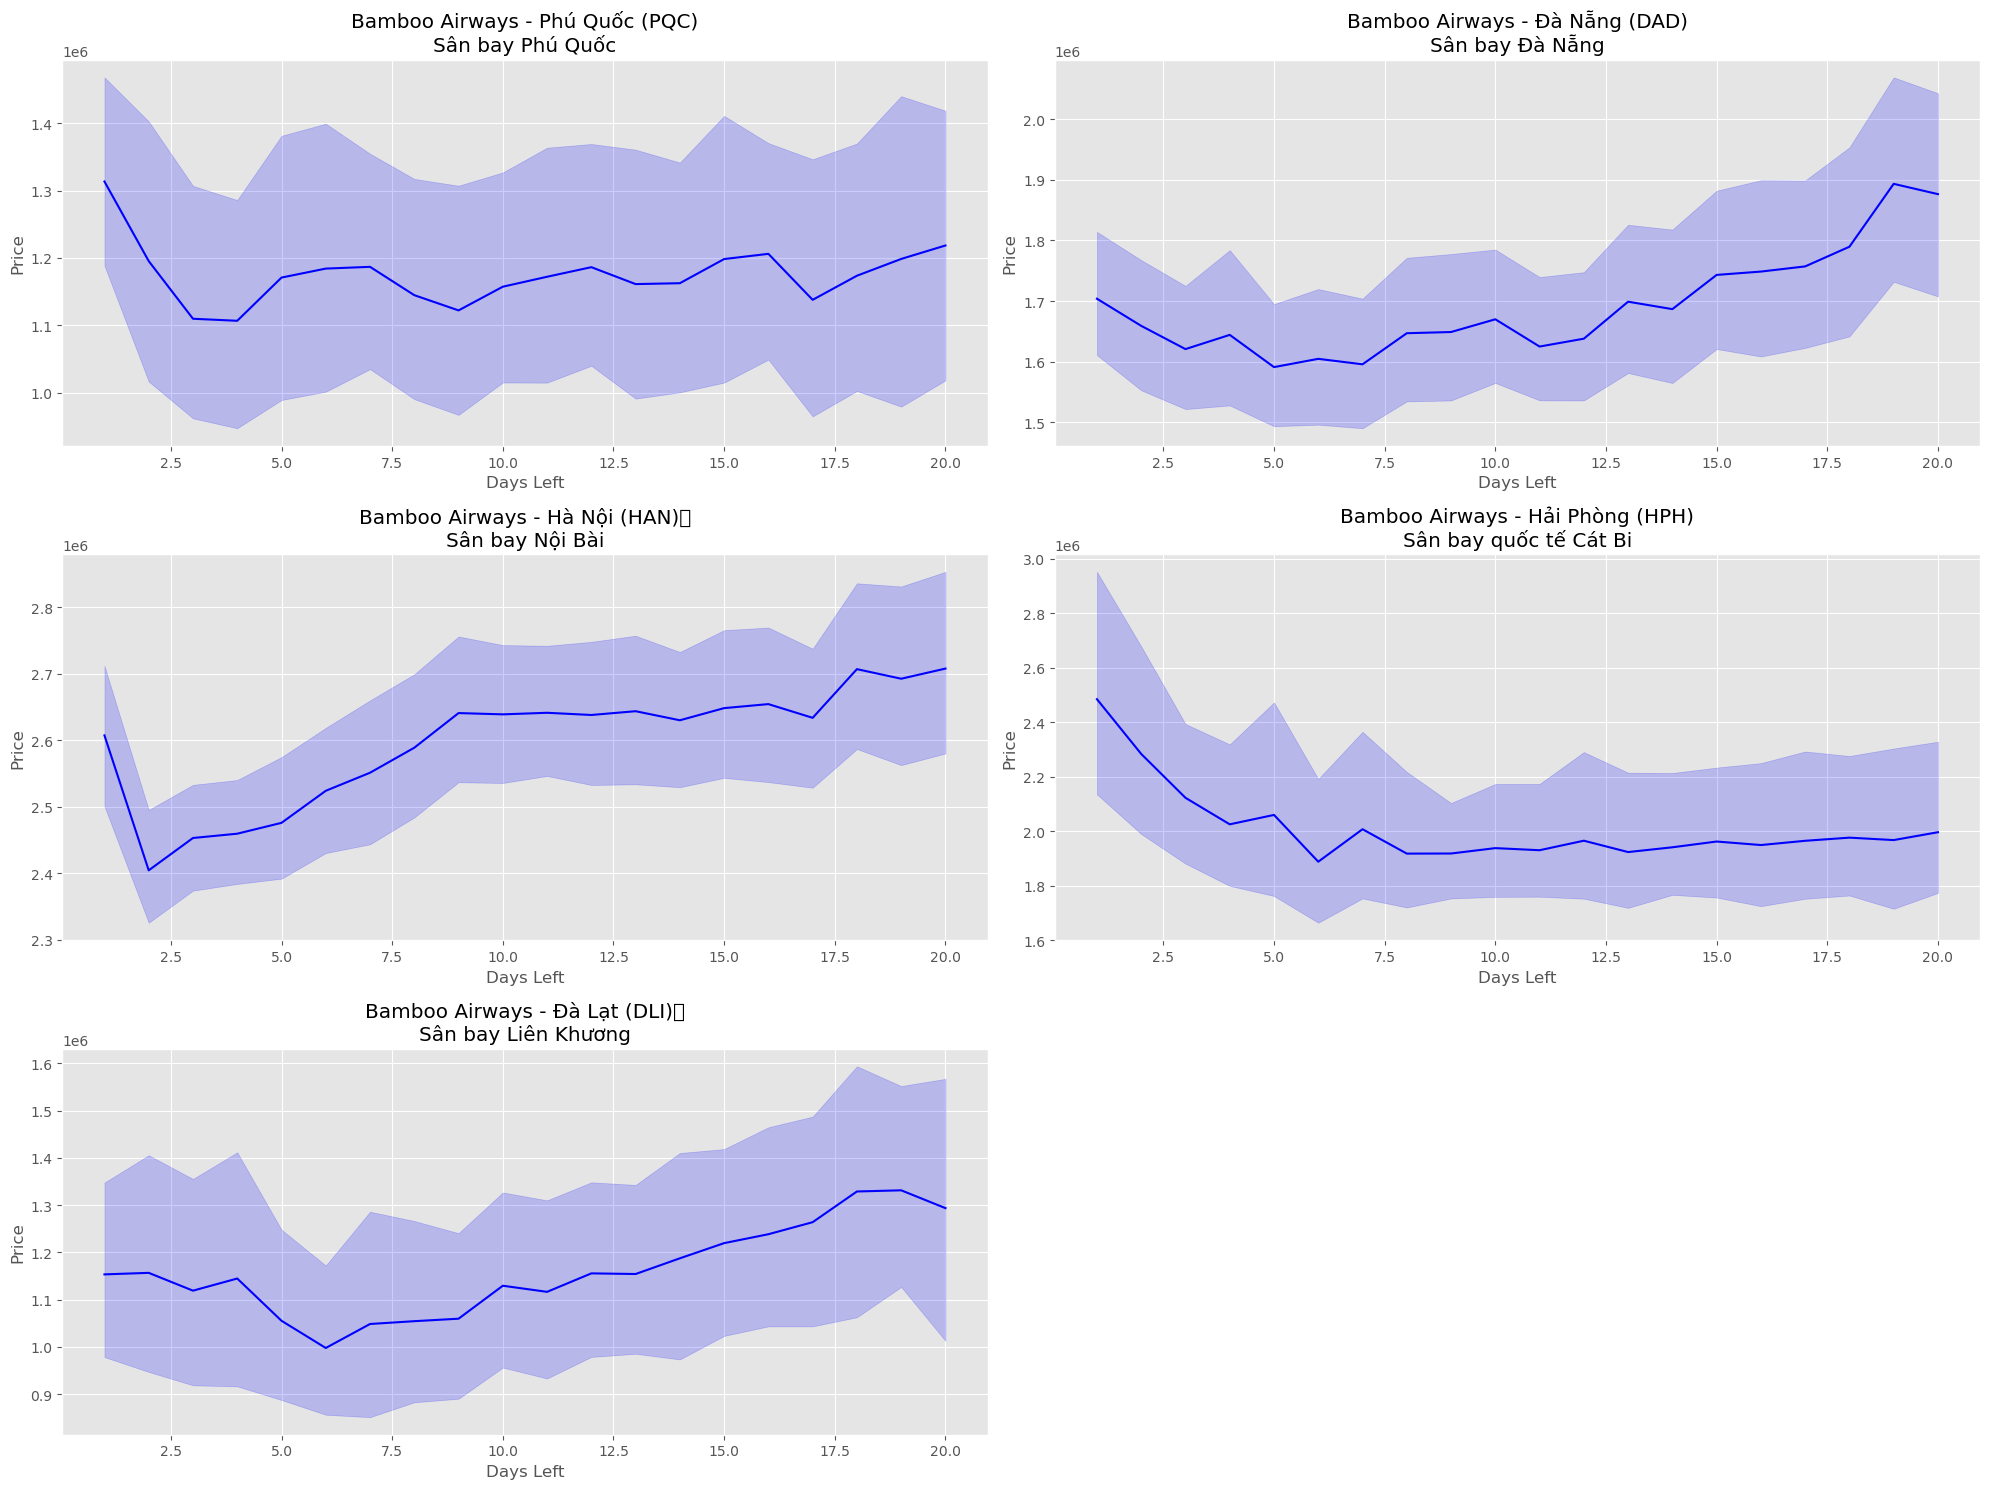

In [79]:
lineplot(Bamboo[Bamboo['days_left'] <= 20])

**Vietravel**

Destination: Phú Quốc (PQC)
Sân bay Phú Quốc, count: 370
Destination: Đà Nẵng (DAD)
Sân bay Đà Nẵng, count: 383
Destination: Hà Nội (HAN)
Sân bay Nội Bài, count: 380


) missing from font(s) DejaVu Sans.emp\ipykernel_18120\2195073531.py:22: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


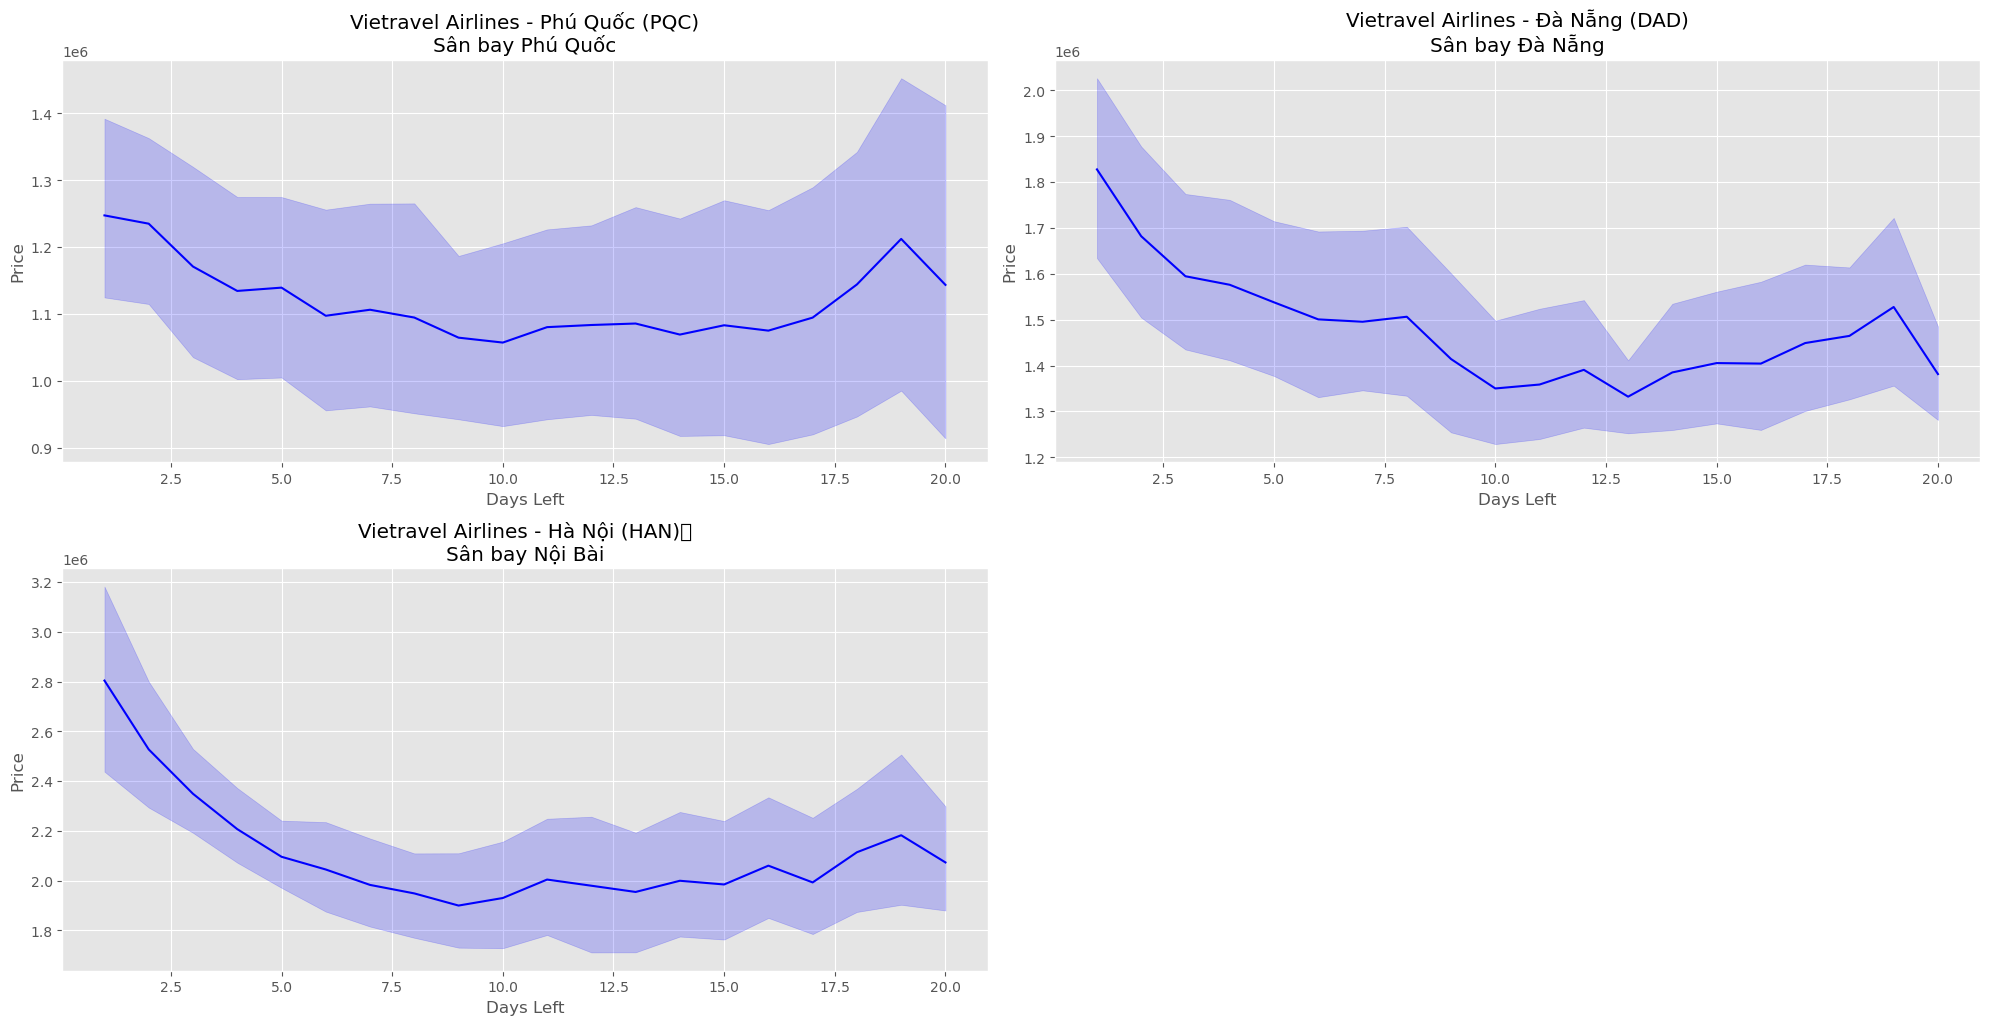

In [80]:
lineplot(Vietravel[Vietravel['days_left'] <= 20])

**Vietjet**

Destination: Phú Quốc (PQC)
Sân bay Phú Quốc, count: 2214
Destination: Đà Nẵng (DAD)
Sân bay Đà Nẵng, count: 5340
Destination: Hà Nội (HAN)
Sân bay Nội Bài, count: 8837
Destination: Hải Phòng (HPH)
Sân bay quốc tế Cát Bi, count: 2645
Destination: Đà Lạt (DLI)
Sân bay Liên Khương, count: 486
Destination: Nha Trang (CXR)
Sân bay Cam Ranh, count: 1121


) missing from font(s) DejaVu Sans.emp\ipykernel_18120\2195073531.py:22: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


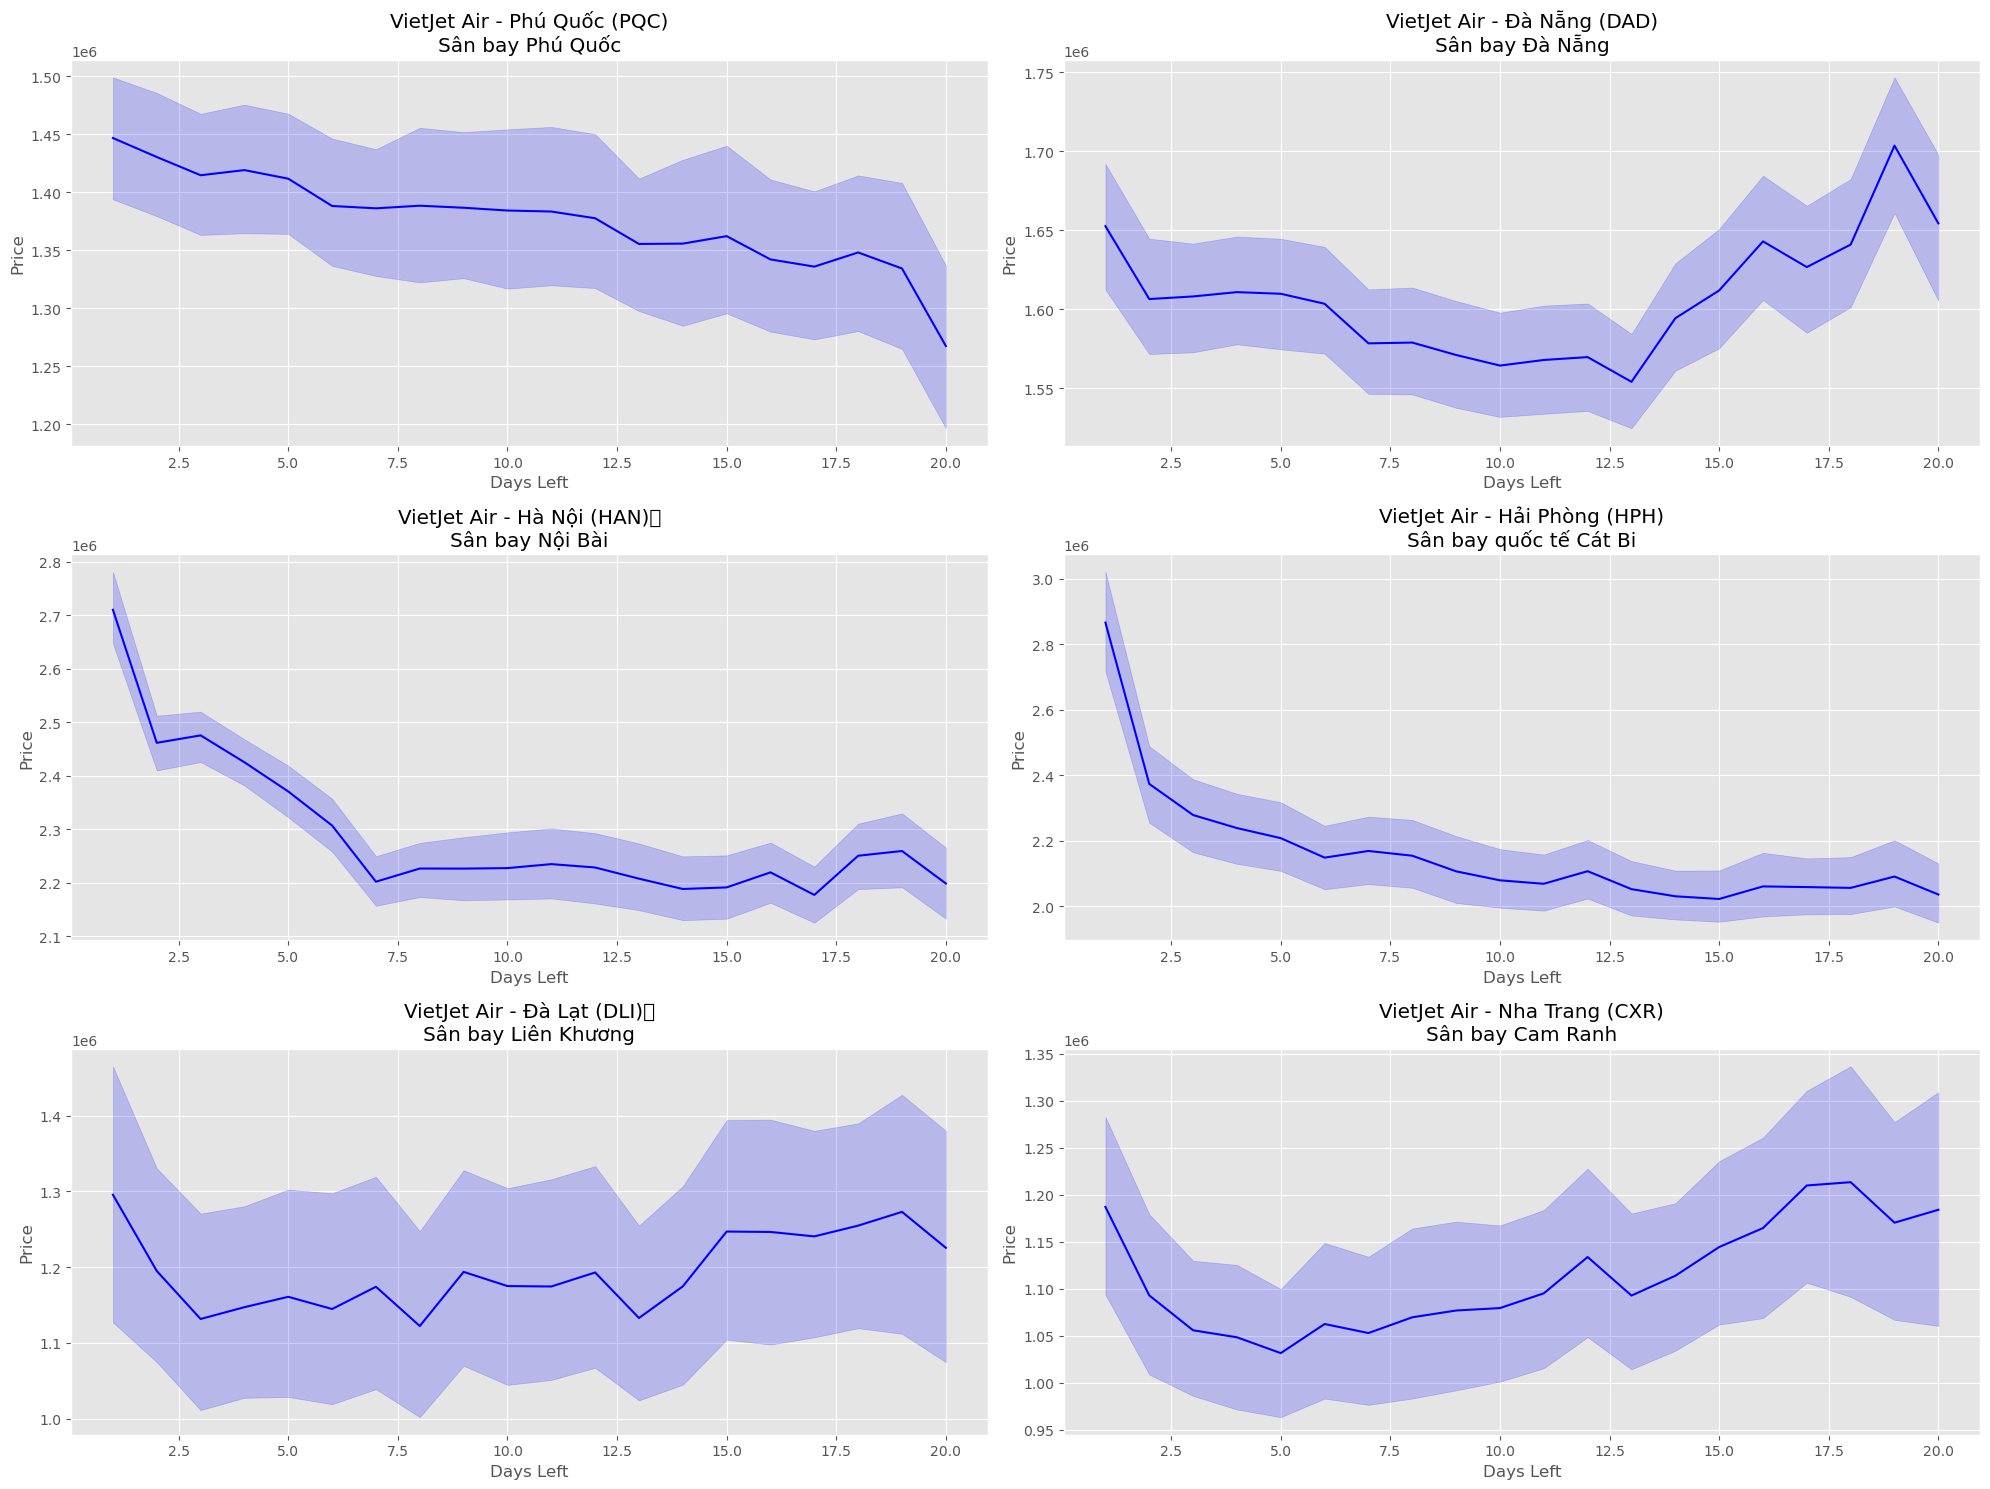

In [81]:
lineplot(Vietjet[Vietjet['days_left'] <= 20])

**Vietnam**

Destination: Phú Quốc (PQC)
Sân bay Phú Quốc, count: 2200
Destination: Đà Nẵng (DAD)
Sân bay Đà Nẵng, count: 5856
Destination: Hà Nội (HAN)
Sân bay Nội Bài, count: 8182
Destination: Hải Phòng (HPH)
Sân bay quốc tế Cát Bi, count: 1176
Destination: Đà Lạt (DLI)
Sân bay Liên Khương, count: 1124
Destination: Nha Trang (CXR)
Sân bay Cam Ranh, count: 2051


) missing from font(s) DejaVu Sans.emp\ipykernel_18120\2195073531.py:22: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


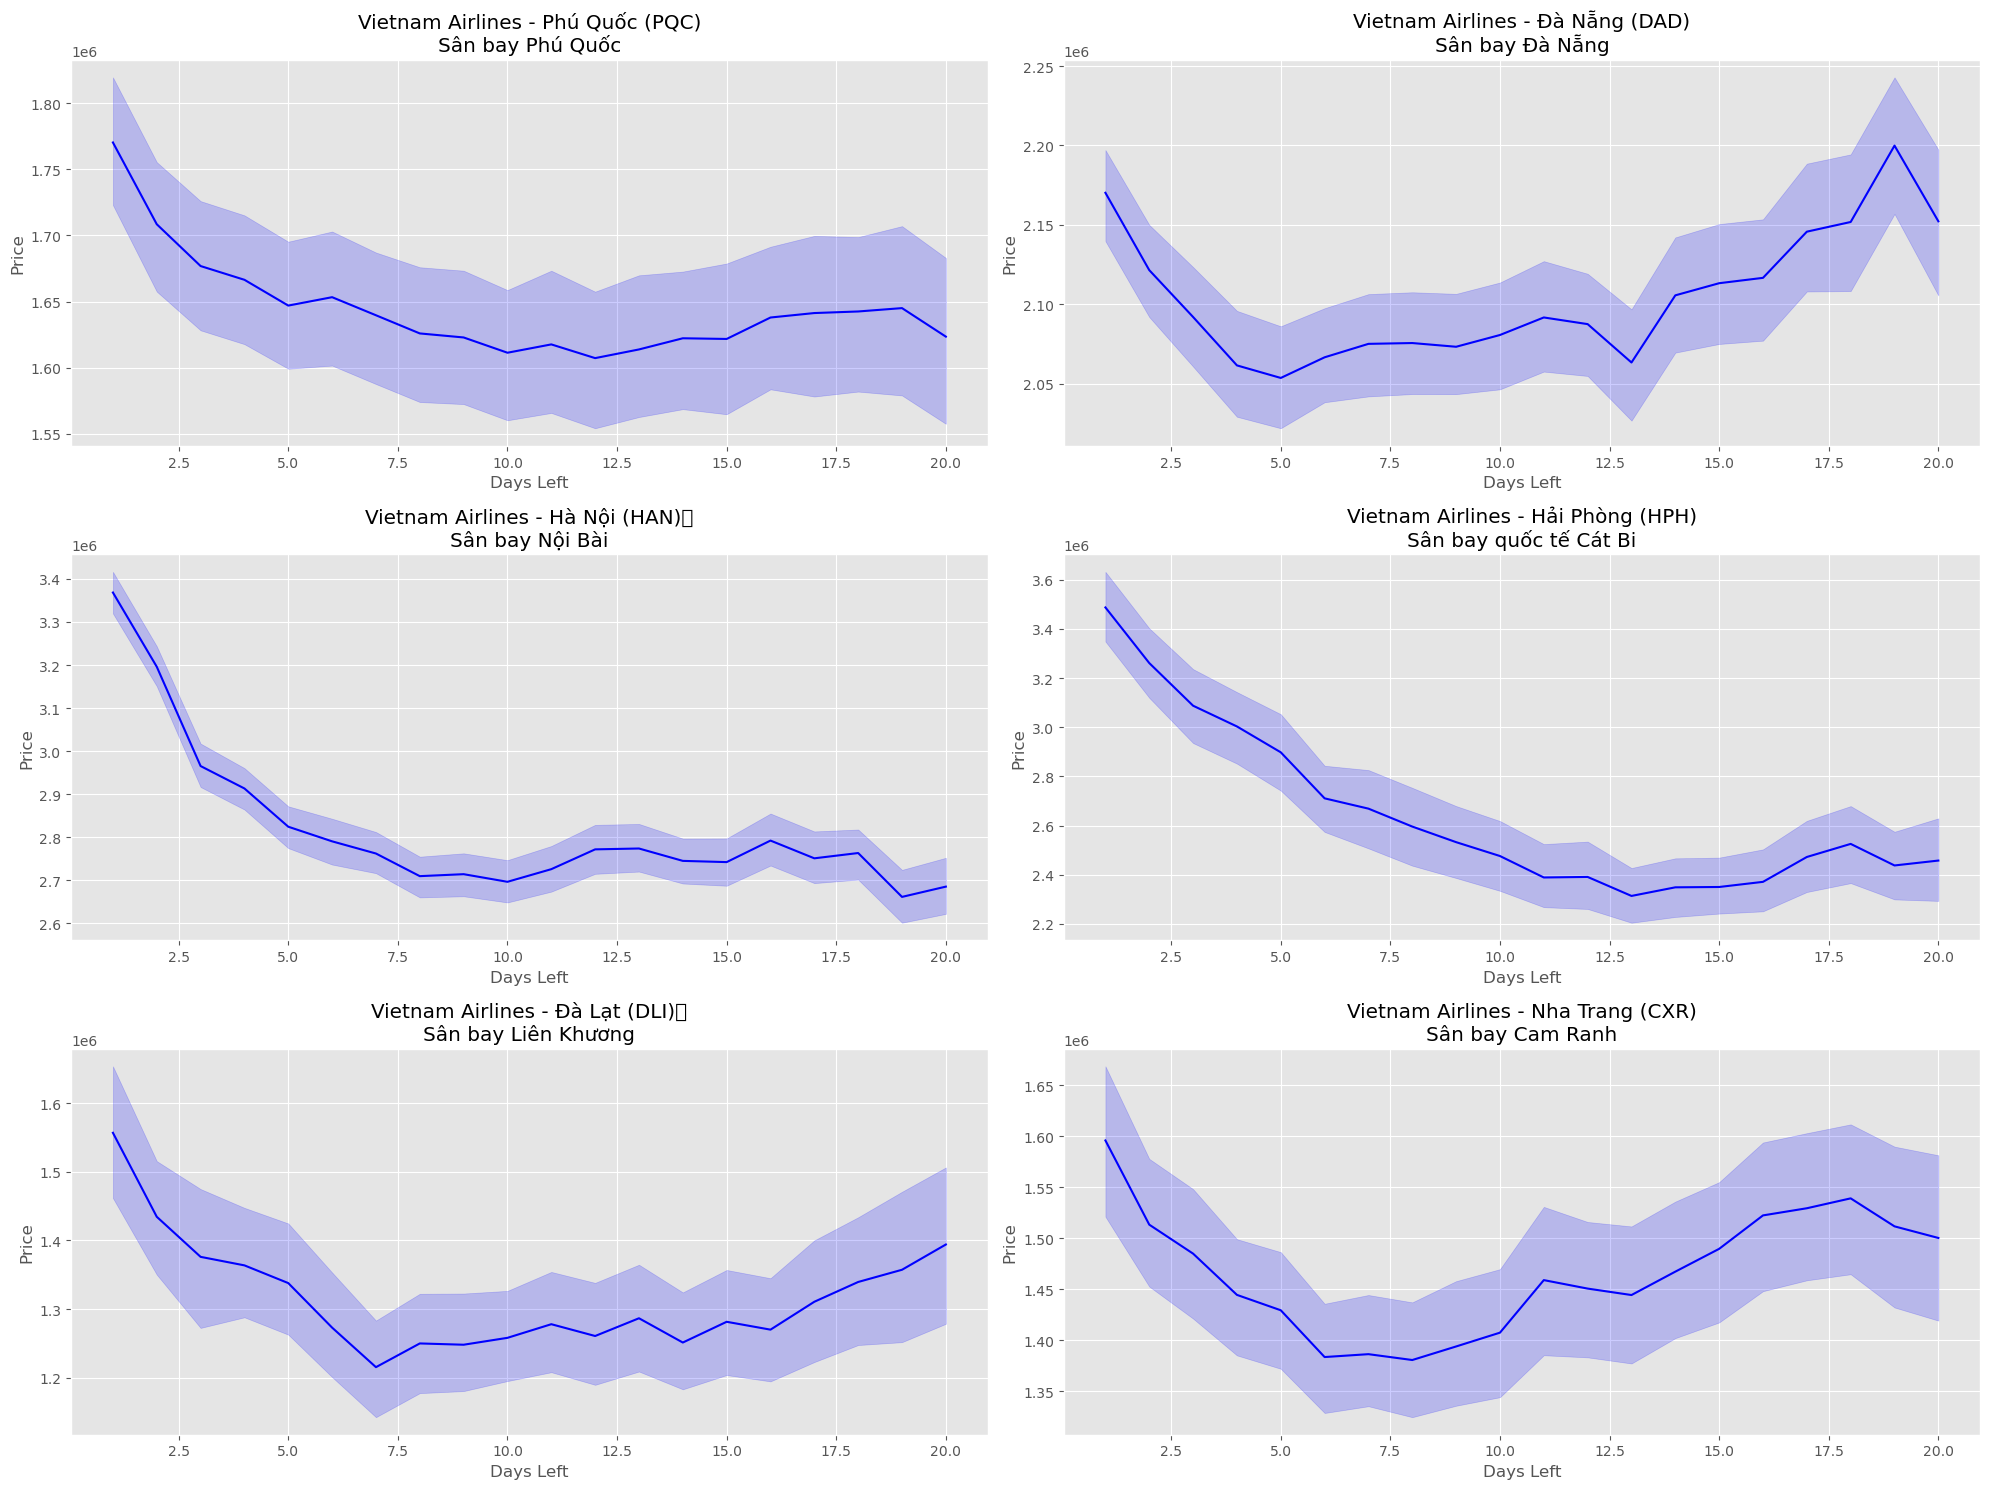

In [82]:
lineplot(Vietnam[Vietnam['days_left'] <= 20])

# TRAIN _ TEST 

In [83]:
len(Bamboo['destination'].unique())

5

In [84]:
data['brand'].unique()

array(['Bamboo Airways', 'Vietravel Airlines', 'Vietnam Airlines',
       'VietJet Air'], dtype=object)

In [85]:
test_data = []

def split_train_test(data):
   train = []
   test = []

   for des in data['destination'].unique():
      df = data[data['destination'] == des]
      for i in range(2):
         id = df['id'].sample(n=1, random_state=42).values[0]
         if df['brand'].unique()[0] == 'Vietravel Airlines':
            days_left = 7
         else:
            days_left = np.random.randint(10, 15)
         flight_by_id = df[(df['id'] == id) & (df['days_left'] <= days_left)]
         test.append(flight_by_id)
         test_data.append(flight_by_id)
         df = df.drop(flight_by_id.index)

      sample_df = df.sample(frac=0.18, random_state=42)
      train.append(df.drop(sample_df.index))
      test.append(sample_df)
   train = pd.concat(train, ignore_index=True)
   test = pd.concat(test, ignore_index=True)
   return train, test

In [86]:
Bamboo_train, Bamboo_test = split_train_test(Bamboo)
Vietjet_train, Vietjet_test = split_train_test(Vietjet)
Vietnam_train, Vietnam_test = split_train_test(Vietnam)
Vietravel_train, Vietravel_test = split_train_test(Vietravel)

In [87]:
Bamboo_train.shape, Bamboo_test.shape, Vietjet_train.shape, Vietjet_test.shape, Vietnam_train.shape, Vietnam_test.shape, Vietravel_train.shape, Vietravel_test.shape

((2516, 23),
 (671, 23),
 (17244, 23),
 (3918, 23),
 (17154, 23),
 (3872, 23),
 (929, 23),
 (245, 23))

# OUTLIERS

In [88]:
def threshold_outlier(des, data):
   df = data[data['destination'] == des]
   q1 = df['price'].quantile(0.25)
   q3 = df['price'].quantile(0.75)
   iqr = q3 - q1
   lower_bound = q1 - 1.5 * iqr
   upper_bound = q3 + 1.5 * iqr
   return lower_bound, upper_bound

In [89]:
def process_outliers(data):
   for des in data['destination'].unique():
      lower, upper = threshold_outlier(des, data)
      condition = (
            (data['destination'] == des) &
            ((data['price'] < lower) | (data['price'] > upper))
      )
      data.loc[condition, 'price'] = upper
   return data

In [90]:
Bamboo_train = process_outliers(Bamboo_train)
Vietjet_train = process_outliers(Vietjet_train)
Vietnam_train = process_outliers(Vietnam_train)
Vietravel_train = process_outliers(Vietravel_train)

C:\Users\NGUYENTRAM\AppData\Local\Temp\ipykernel_18120\611414442.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3892862.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[condition, 'price'] = upper
C:\Users\NGUYENTRAM\AppData\Local\Temp\ipykernel_18120\611414442.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2498657.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[condition, 'price'] = upper
C:\Users\NGUYENTRAM\AppData\Local\Temp\ipykernel_18120\611414442.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3061117.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[condition, 'price

In [91]:
def boxplot(data):
   for des in data['destination'].unique():
      print(f'Destination: {des}, count: {len(data[data["destination"] == des])}')
      df = data[data['destination'] == des]
   plt.figure(figsize=(15, 5))
   sns.boxplot(x='destination', y='price', data=data, palette='hls')
   plt.title(f'Boxplot of {df['brand'].unique()[0]} by destination')
   plt.show()

Destination: Phú Quốc (PQC)
Sân bay Phú Quốc, count: 193
Destination: Đà Nẵng (DAD)
Sân bay Đà Nẵng, count: 482
Destination: Hà Nội (HAN)
Sân bay Nội Bài, count: 1528
Destination: Hải Phòng (HPH)
Sân bay quốc tế Cát Bi, count: 150
Destination: Đà Lạt (DLI)
Sân bay Liên Khương, count: 163


C:\Users\NGUYENTRAM\AppData\Local\Temp\ipykernel_18120\2400653087.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='destination', y='price', data=data, palette='hls')
) missing from font(s) DejaVu Sans.\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


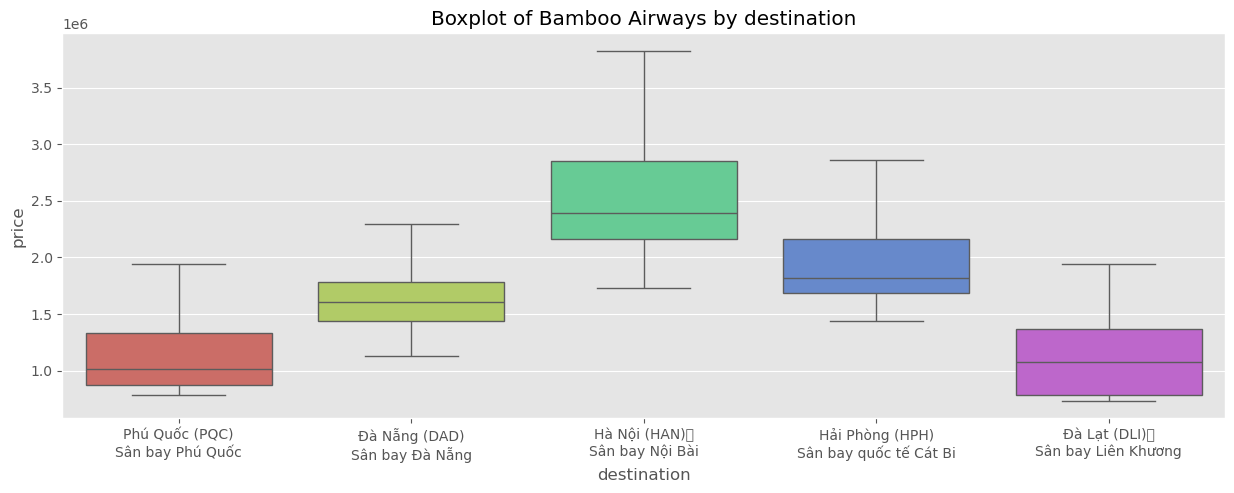

In [92]:
boxplot(Bamboo_train)

Destination: Phú Quốc (PQC)
Sân bay Phú Quốc, count: 1893
Destination: Đà Nẵng (DAD)
Sân bay Đà Nẵng, count: 4607
Destination: Hà Nội (HAN)
Sân bay Nội Bài, count: 7227
Destination: Hải Phòng (HPH)
Sân bay quốc tế Cát Bi, count: 2235
Destination: Đà Lạt (DLI)
Sân bay Liên Khương, count: 380
Destination: Nha Trang (CXR)
Sân bay Cam Ranh, count: 902


C:\Users\NGUYENTRAM\AppData\Local\Temp\ipykernel_18120\2400653087.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='destination', y='price', data=data, palette='hls')
) missing from font(s) DejaVu Sans.\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


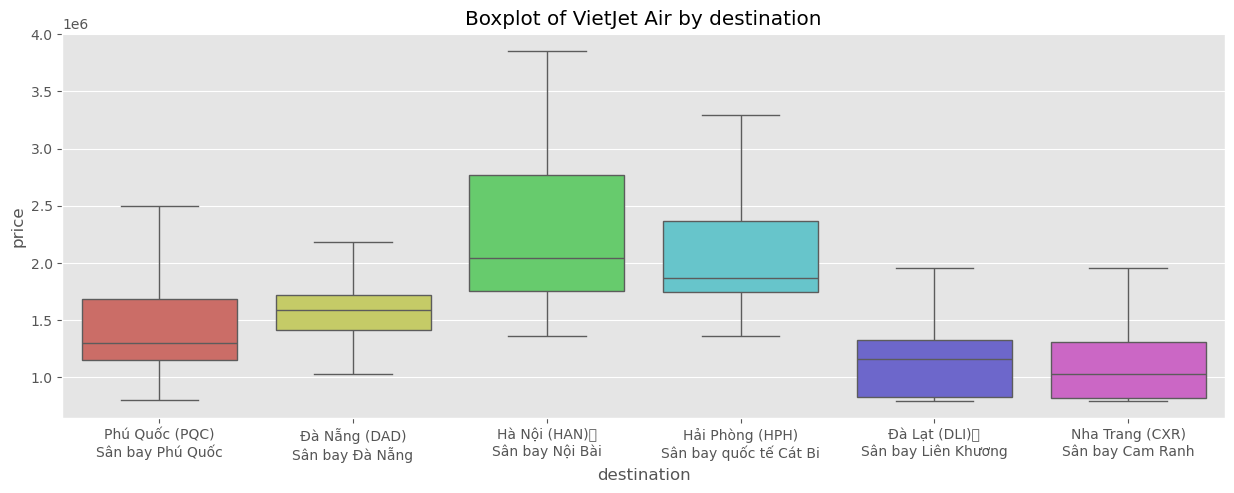

In [93]:
boxplot(Vietjet_train)

Destination: Phú Quốc (PQC)
Sân bay Phú Quốc, count: 308
Destination: Đà Nẵng (DAD)
Sân bay Đà Nẵng, count: 320
Destination: Hà Nội (HAN)
Sân bay Nội Bài, count: 301


C:\Users\NGUYENTRAM\AppData\Local\Temp\ipykernel_18120\2400653087.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='destination', y='price', data=data, palette='hls')
) missing from font(s) DejaVu Sans.\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


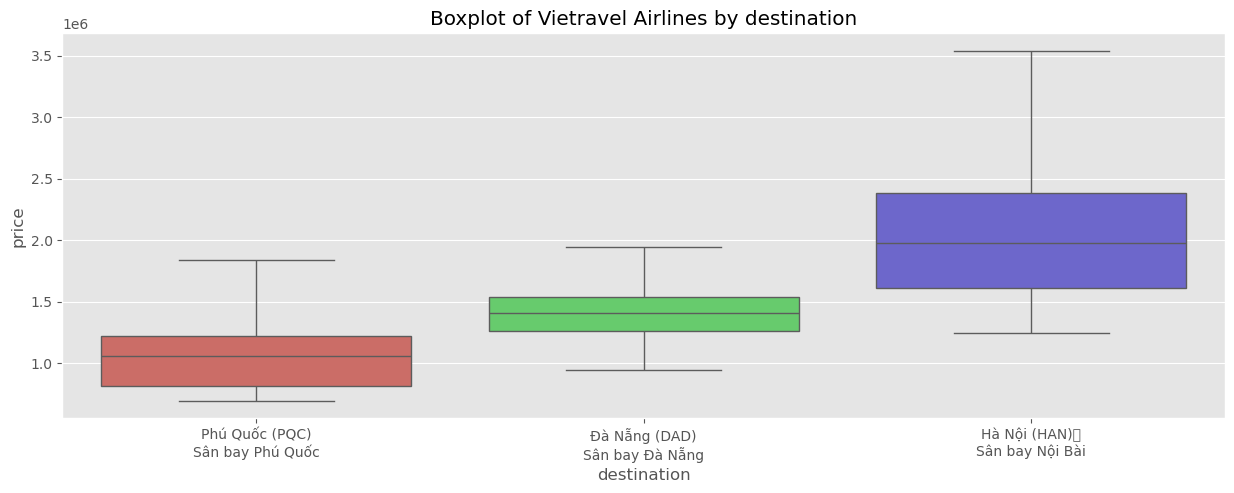

In [94]:
boxplot(Vietravel_train)

Destination: Phú Quốc (PQC)
Sân bay Phú Quốc, count: 1865
Destination: Đà Nẵng (DAD)
Sân bay Đà Nẵng, count: 5018
Destination: Hà Nội (HAN)
Sân bay Nội Bài, count: 6694
Destination: Hải Phòng (HPH)
Sân bay quốc tế Cát Bi, count: 1000
Destination: Đà Lạt (DLI)
Sân bay Liên Khương, count: 906
Destination: Nha Trang (CXR)
Sân bay Cam Ranh, count: 1671


C:\Users\NGUYENTRAM\AppData\Local\Temp\ipykernel_18120\2400653087.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='destination', y='price', data=data, palette='hls')
) missing from font(s) DejaVu Sans.\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


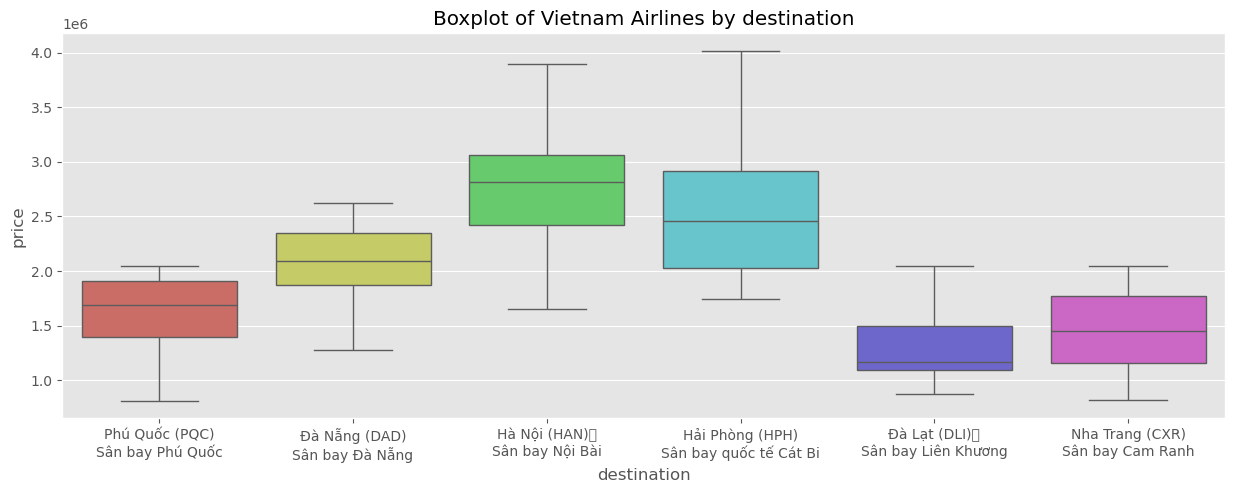

In [95]:
boxplot(Vietnam_train)

# Modeling

In [96]:
from sklearn.preprocessing import StandardScaler

def scale_data(X_train, X_test):
   scaler = StandardScaler()  
   # mmscaler = MinMaxScaler(feature_range=(0, 1))
   X_train = scaler.fit_transform(X_train)
   X_test = scaler.transform(X_test)
   X_train=pd.DataFrame(X_train)
   X_test=pd.DataFrame(X_test)
   return X_train, X_test

In [97]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn import linear_model
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor, ExtraTreesRegressor
import xgboost as xgb
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import metrics

In [98]:
modelAda = AdaBoostRegressor()
modelETR = ExtraTreesRegressor(n_estimators=100)
modelmlg = LinearRegression()
modeldcr = DecisionTreeRegressor()
modelbag = BaggingRegressor()
modelrfr = RandomForestRegressor()
modelXGR = xgb.XGBRegressor()
modelKNN = KNeighborsRegressor(n_neighbors=5)
modelRE=Ridge()
modelLO=linear_model.Lasso(alpha=0.1)
modelGBR = GradientBoostingRegressor()

In [99]:
MM = [modelAda, modelETR, modelmlg, modeldcr, modelrfr, modelKNN, modelGBR, modelXGR, modelbag,modelRE,modelLO]
models=['AdaBoost', 'ExtraTreesRegressor', 'LinearRegression','DecisionTreeRegressor','RandomForestRegressor','KNeighborsRegressor','GradientBoostingRegressor','XGBRegressor','BaggingRegressor','Ridge Regression','Lasso Regression']
def modeling(X_train, X_test, y_train, y_test, Results, brand):
    count = 0
    for model in MM:
        # Fit the model with train data
        model.fit(X_train, y_train)
        
        # Predict the model with test data
        y_pred = model.predict(X_test)
        
        # Print the model name
        # print('Model Name: ', models)
        # print('R2_score:', round(metrics.r2_score(y_test, y_pred),6))
        # print('------------------------------------------------------------------------------------------------------------')
        #-------------------------------------------------------------------------------------------
        new_row = {'Brand' : brand,
                   'Model Name' : models[count],
                   'R2_score' : round(metrics.r2_score(y_test, y_pred),6)}
        Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)
        count += 1
    return Results, y_pred

In [100]:
Bamboo_train.head()

,id,brand,price,destination,trip_mins,is_holiday,days_left,start_hour_Afternoon,start_hour_EarlyMorning,start_hour_Evening,start_hour_LateNight,start_hour_Morning,end_hour_Afternoon,end_hour_EarlyMorning,end_hour_Evening,end_hour_LateNight,end_hour_Morning,hand_luggage_7,hand_luggage_10,hand_luggage_12,checked_baggage_0,checked_baggage_20,checked_baggage_23
0,PQC0002,Bamboo Airways,1245267.0,Phú Quốc (PQC)\nSân bay Phú Quốc,60,2,1,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False
1,PQC0003,Bamboo Airways,869953.0,Phú Quốc (PQC)\nSân bay Phú Quốc,60,2,2,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False
2,PQC0004,Bamboo Airways,1013756.0,Phú Quốc (PQC)\nSân bay Phú Quốc,60,2,3,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False
3,PQC0005,Bamboo Airways,782244.0,Phú Quốc (PQC)\nSân bay Phú Quốc,60,0,4,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False
4,PQC0007,Bamboo Airways,1222830.0,Phú Quốc (PQC)\nSân bay Phú Quốc,60,1,8,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False


In [101]:
def split_and_model(train, test):
   Results = pd.DataFrame(columns=['Brand', 'Model Name', 'R2_score'])

   # Split the data into features and target variable
   X_train = train.drop(columns=['price', 'brand', 'id'])
   y_train = train['price']
   X_test = test.drop(columns=['price', 'brand', 'id'])
   y_test = test['price']

   # Convert categorical variables to dummy variables
   X_train = pd.get_dummies(X_train, columns=['destination'])
   X_test = pd.get_dummies(X_test, columns=['destination'])

   # Scale the data
   X_train, X_test = scale_data(X_train, X_test)

   # Split and model for each destination
   Results, y_pred = modeling(X_train, X_test, y_train, y_test, Results, train['brand'][0])
   return Results, y_pred

In [102]:
Bamboo_results, Bamboo_pred = split_and_model(Bamboo_train, Bamboo_test)
Vietjet_results, Vietjet_pred = split_and_model(Vietjet_train, Vietjet_test)
Vietravel_results, Vietravel_pred = split_and_model(Vietravel_train, Vietravel_test)
Vietnam_results, Vietnam_pred = split_and_model(Vietnam_train, Vietnam_test)

# Combine all results into a single DataFrame
all_results = pd.concat([Bamboo_results, Vietjet_results, Vietravel_results, Vietnam_results], ignore_index=True)

C:\Users\NGUYENTRAM\AppData\Local\Temp\ipykernel_18120\3853082926.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)
c:\Users\NGUYENTRAM\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.155e+13, tolerance: 1.320e+11
  model = cd_fast.enet_coordinate_descent(
C:\Users\NGUYENTRAM\AppData\Local\Temp\ipykernel_18120\3853082926.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this w

In [103]:
pivot_df = all_results.pivot(index='Model Name', columns='Brand', values='R2_score')
pivot_df

Brand,Bamboo Airways,VietJet Air,Vietnam Airlines,Vietravel Airlines
Model Name,,,,
AdaBoost,0.874907,0.683824,0.712789,0.643508
BaggingRegressor,0.887733,0.741521,0.743978,0.645670
DecisionTreeRegressor,0.880453,0.735060,0.730325,0.614984
ExtraTreesRegressor,0.881896,0.735655,0.736105,0.617865
GradientBoostingRegressor,0.902760,0.768403,0.766784,0.723546
KNeighborsRegressor,0.898185,0.702681,0.714350,0.716621
Lasso Regression,0.885739,0.598552,0.678615,0.670265
LinearRegression,0.885427,0.598566,0.678615,0.670265
RandomForestRegressor,0.891436,0.745846,0.747104,0.656361


In [104]:
Bamboo_results, Bamboo_pred = split_and_model(Bamboo_train, Bamboo_test)
Bamboo_results_2 = pd.concat([Bamboo_test['price'], pd.DataFrame(Bamboo_pred, columns=['Predicted Price'])], axis=1)

C:\Users\NGUYENTRAM\AppData\Local\Temp\ipykernel_18120\3853082926.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)
c:\Users\NGUYENTRAM\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.155e+13, tolerance: 1.320e+11
  model = cd_fast.enet_coordinate_descent(


In [105]:
Bamboo_results_2['price'] = Bamboo_results_2['price'].apply(lambda x: int(x))
Bamboo_results_2['Predicted Price'] = Bamboo_results_2['Predicted Price'].apply(lambda x: int(x))

Bamboo_results_2 = Bamboo_results_2.sort_values(by='price')
Bamboo_results_2.head()

,price,Predicted Price
637,734450,811512
648,747353,859039
0,754708,972035
1,754708,967282
622,761248,1063927


# Predict

In [106]:
def create_data(X):
   expanded_rows = []

   for _, row in X.iterrows():
      for day in range(row['days_left'] - 1, 0, -1):  # giảm từ days_left về 1
         new_row = row.copy()
         new_row['days_left'] = day
         expanded_rows.append(new_row)

   return pd.DataFrame(expanded_rows).reset_index(drop=True)


In [107]:
def adjust(X_test, Y_test):
   for id in X_test['id'].unique():
      y_connt = Y_test[Y_test['id'] == id].value_counts()
      x_connt = X_test[X_test['id'] == id].value_counts()
      if y_connt.equals(x_connt):
         continue
      days_left = Y_test[Y_test['id'] == id]['days_left'].unique()
      X_test = X_test[~((X_test['id'] == id) & ~(X_test['days_left'].isin(days_left)))]
   return X_test.reset_index(drop=True)

In [108]:
def lineplot_y_pred(data):
   plt.figure(figsize=(20,8))
   sns.lineplot(data=data,x='days_left',y='Actual Price',color='red')
   sns.lineplot(data=data,x='days_left',y='Predicted Price',color='blue')
   plt.title('Days Left For Departure Versus Actual Ticket Price and Predicted Ticket Price',fontsize=20)
   plt.legend(labels=['Actual Price','Predicted Price'],fontsize=19)
   plt.xlabel('Days Left for Departure',fontsize=15)
   plt.ylabel('Actual and Predicted Price',fontsize=15)
   plt.show()

In [109]:
test_data = pd.concat(test_data, ignore_index=True)

In [110]:
def predict(brand, train):
   test = test_data[test_data['brand'] == brand].copy()
   X_test = []
   Y_test = []
   for des in test['destination'].unique():
      for id in test['id'].unique():
         df = test[(test['destination'] == des) & (test['id'] == id)].copy().sort_values(by='days_left', ascending=False)
         X_test.append(df.head(1))
         df = df.drop(df.head(1).index)
         Y_test.append(df)

   X_test = pd.concat(X_test, ignore_index=True)
   Y_test = pd.concat(Y_test, ignore_index=True)

   X_test = create_data(X_test)
   X_test = adjust(X_test, Y_test)

   X_test = X_test.drop(columns=['id', 'brand', 'price'])
   Y_test = Y_test['price']

   X_train = train.drop(columns=['price', 'brand', 'id'])
   y_train = train['price']

   X_test_model = pd.get_dummies(X_test, columns=['destination'])
   X_train = pd.get_dummies(X_train, columns=['destination'])

   X_train_scaled, X_test_scaled = scale_data(X_train, X_test_model)

   modelGBR.fit(X_train_scaled, y_train)

   y_pred = modelGBR.predict(X_test_scaled)
   output = pd.DataFrame({'Actual Price': Y_test, 'Predicted Price': y_pred}, index=Y_test.index)

   result = X_test.copy()
   result['Actual Price'] = output['Actual Price']
   result['Predicted Price'] = output['Predicted Price']

   print(f'Brand: {brand}, R2_score: {round(metrics.r2_score(Y_test, y_pred), 6)}')
   lineplot_y_pred(result)

   return result

Brand: Bamboo Airways, R2_score: 0.92952


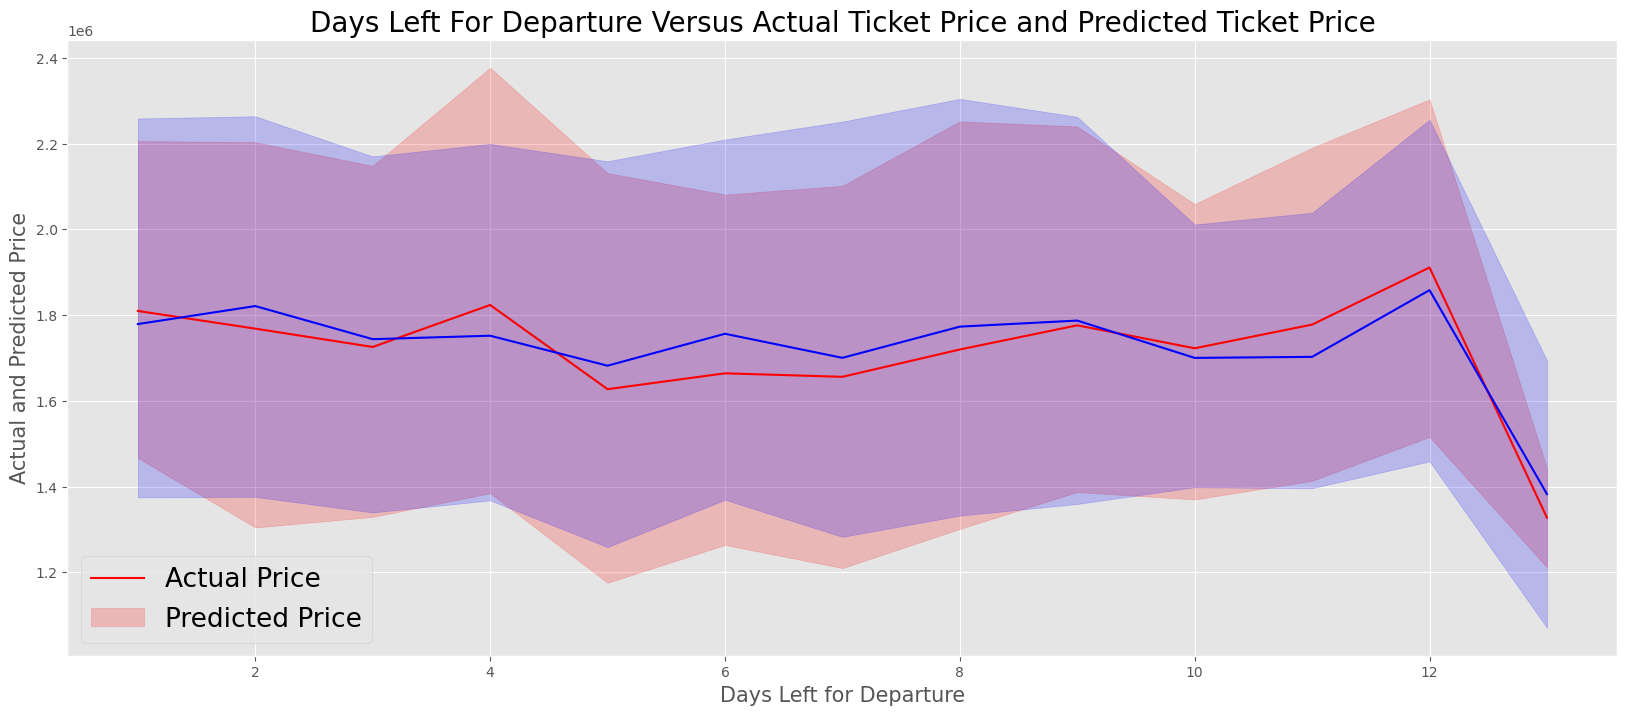

In [111]:
Bamboo_predicted = predict('Bamboo Airways', Bamboo_train)

Brand: VietJet Air, R2_score: 0.863219


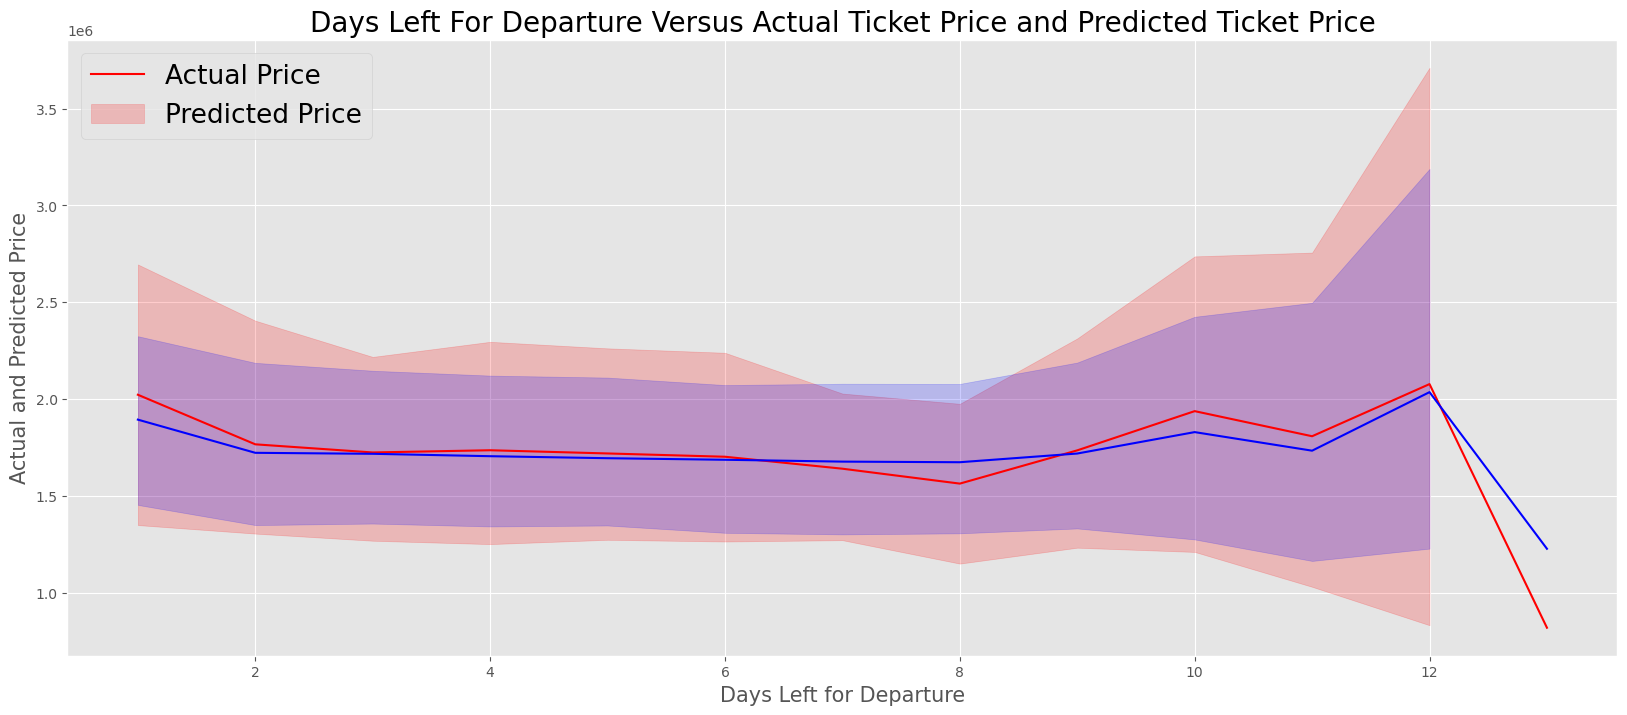

In [112]:
Vietjet_predicted = predict('VietJet Air', Vietjet_train)

Brand: Vietnam Airlines, R2_score: 0.744182


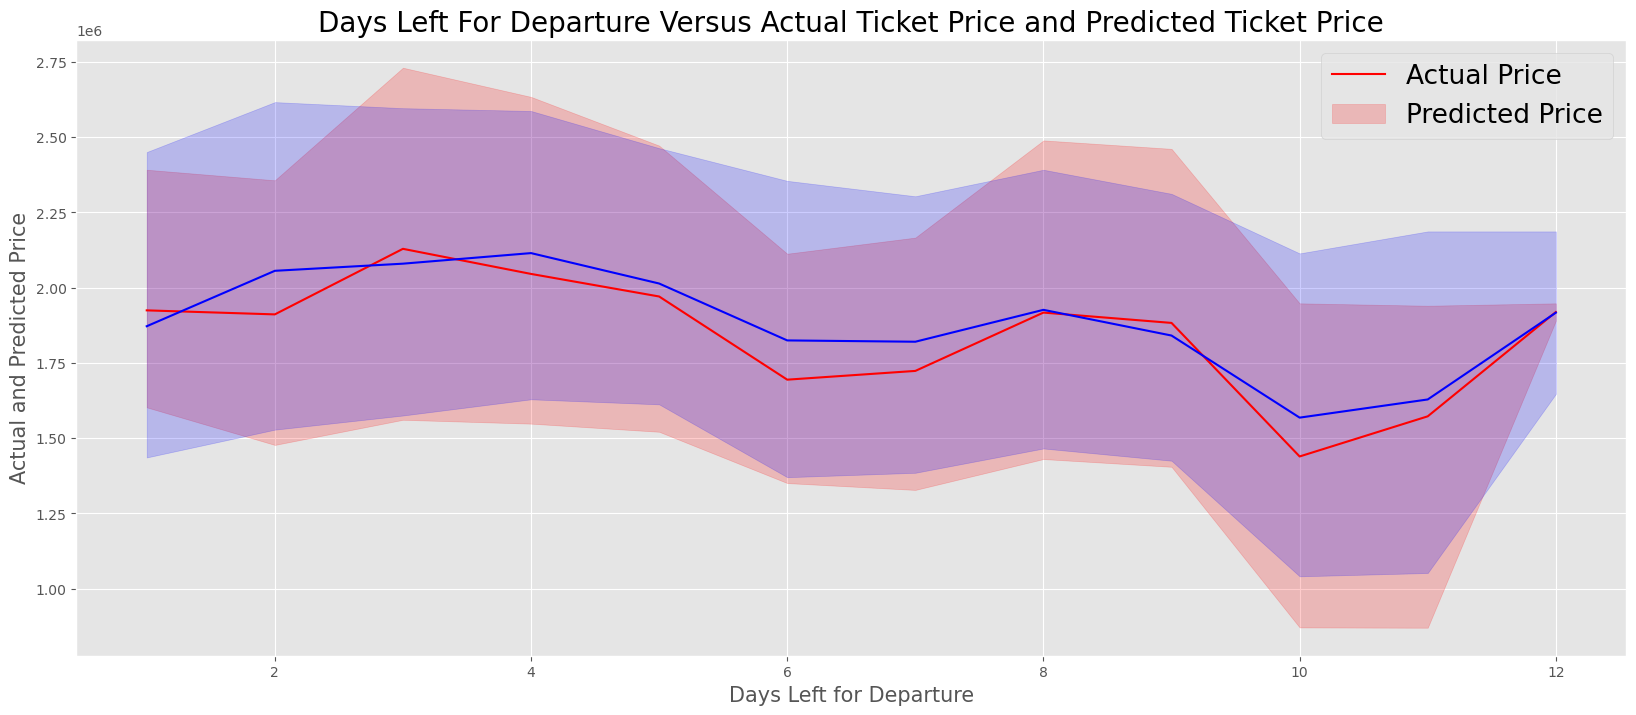

In [113]:
Vietnam_predicted = predict('Vietnam Airlines', Vietnam_train)

Brand: Vietravel Airlines, R2_score: 0.748937


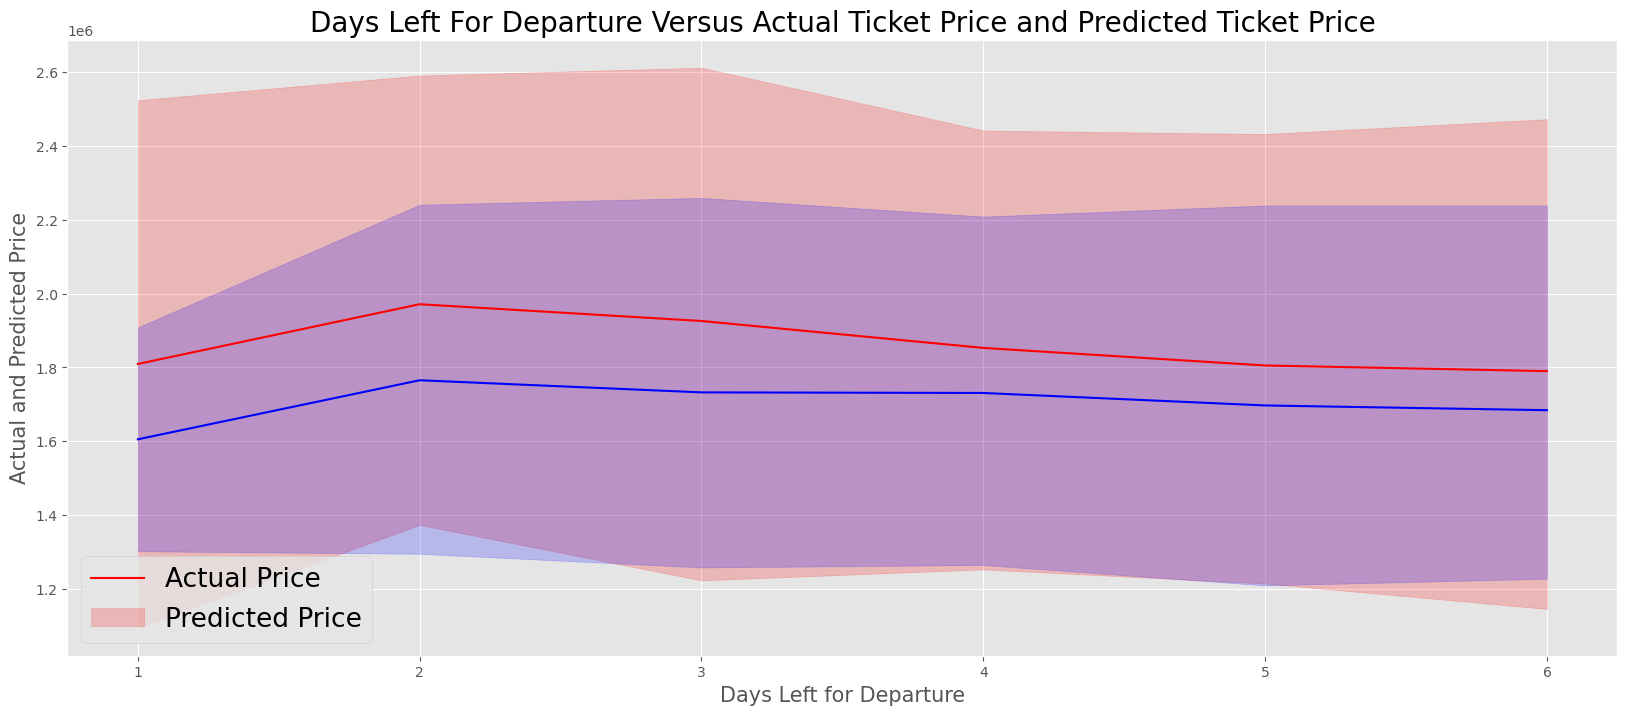

In [114]:
Vietravel_predicted = predict('Vietravel Airlines', Vietravel_train)

# tính threshold_price rẻ cho từng brand
- lấy 10% số giá vé dự đoán rẻ nhất
- tìm mean của 10% số lượng giá đó

In [135]:
def threshold_predicted(data):
    data['is_cheap'] = 0  
    for des in data['destination'].unique():
        des_df = data[data['destination'] == des].copy()
        threshold_prices = des_df['Predicted Price']
        n = max(1,int(0.1 * len(threshold_prices)))
        cheap_threshold = threshold_prices.nsmallest(n)
        cheap_threshold = cheap_threshold.mean()
        data.loc[data['destination'] == des, 'cheap_threshold'] = cheap_threshold
        print(f"{des}: threshold = {cheap_threshold:.2f}")
        cheap_tickets = des_df[des_df['Actual Price'] <= cheap_threshold]
        if cheap_tickets.empty:
            cheapest_price = des_df.loc[des_df['Actual Price'].idxmin()]
            condition = (
                (data['destination'] == des) & (data['days_left'] == cheapest_price['days_left']) & (data['Actual Price'] == cheapest_price['Actual Price'])
            )
            data.loc[condition,'is_cheap'] = 1
        else:
            min_price = (
                cheap_tickets.sort_values('Actual Price').groupby('days_left', as_index=False).first()
            )
            for _, row in min_price.iterrows():
                condition = (
                    (data['destination'] == des) & (data['days_left'] == row['days_left']) & (data['Actual Price'] == row['Actual Price'])
                )
                data.loc[condition,'is_cheap'] = 1
    return data

In [136]:
Bamboo_predicted = threshold_predicted(Bamboo_predicted)
Bamboo_predicted

Phú Quốc (PQC)
Sân bay Phú Quốc: threshold = 981635.83
Đà Nẵng (DAD)
Sân bay Đà Nẵng: threshold = 1577549.56
Hà Nội (HAN)
Sân bay Nội Bài: threshold = 2329245.89
Hải Phòng (HPH)
Sân bay quốc tế Cát Bi: threshold = 1777819.35
Đà Lạt (DLI)
Sân bay Liên Khương: threshold = 957708.52


,destination,trip_mins,is_holiday,days_left,start_hour_Afternoon,start_hour_EarlyMorning,start_hour_Evening,start_hour_LateNight,start_hour_Morning,end_hour_Afternoon,end_hour_EarlyMorning,end_hour_Evening,end_hour_LateNight,end_hour_Morning,hand_luggage_7,hand_luggage_10,hand_luggage_12,checked_baggage_0,checked_baggage_20,checked_baggage_23,Actual Price,Predicted Price,is_cheap,cheap_threshold
0,Phú Quốc (PQC)\nSân bay Phú Quốc,60,0,9,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,869953,985317.192854,1,981635.827013
1,Phú Quốc (PQC)\nSân bay Phú Quốc,60,0,8,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,869953,985317.192854,1,981635.827013
2,Phú Quốc (PQC)\nSân bay Phú Quốc,60,0,7,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,951543,981635.827013,1,981635.827013
3,Phú Quốc (PQC)\nSân bay Phú Quốc,60,0,6,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,754708,981635.827013,1,981635.827013
4,Phú Quốc (PQC)\nSân bay Phú Quốc,60,0,5,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,754708,981635.827013,1,981635.827013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,Đà Lạt (DLI)\r\nSân bay Liên Khương,55,2,5,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,869953,962112.689739,1,957708.521984
105,Đà Lạt (DLI)\r\nSân bay Liên Khương,55,2,4,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,1013756,965860.958839,0,957708.521984
106,Đà Lạt (DLI)\r\nSân bay Liên Khương,55,2,3,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,1041765,969567.950641,0,957708.521984
107,Đà Lạt (DLI)\r\nSân bay Liên Khương,55,2,2,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,947464,953304.354229,1,957708.521984


In [137]:
Vietnam_predicted= threshold_predicted(Vietnam_predicted)
Vietnam_predicted

Phú Quốc (PQC)
Sân bay Phú Quốc: threshold = 1553689.54
Đà Nẵng (DAD)
Sân bay Đà Nẵng: threshold = 1877706.80
Hà Nội (HAN)
Sân bay Nội Bài: threshold = 2355487.89
Hải Phòng (HPH)
Sân bay quốc tế Cát Bi: threshold = 2555188.78
Đà Lạt (DLI)
Sân bay Liên Khương: threshold = 887548.04
Nha Trang (CXR)
Sân bay Cam Ranh: threshold = 1040934.77


,destination,trip_mins,is_holiday,days_left,start_hour_Afternoon,start_hour_EarlyMorning,start_hour_Evening,start_hour_LateNight,start_hour_Morning,end_hour_Afternoon,end_hour_EarlyMorning,end_hour_Evening,end_hour_LateNight,end_hour_Morning,hand_luggage_7,hand_luggage_10,hand_luggage_12,checked_baggage_0,checked_baggage_20,checked_baggage_23,Actual Price,Predicted Price,is_cheap,cheap_threshold
0,Phú Quốc (PQC)\nSân bay Phú Quốc,55,0,12,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,1890108,1.646907e+06,0,1.553690e+06
1,Phú Quốc (PQC)\nSân bay Phú Quốc,55,0,11,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,1907562,1.646907e+06,0,1.553690e+06
2,Phú Quốc (PQC)\nSân bay Phú Quốc,55,0,9,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,1952046,1.665028e+06,0,1.553690e+06
3,Phú Quốc (PQC)\nSân bay Phú Quốc,55,0,8,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,1942056,1.670802e+06,0,1.553690e+06
4,Phú Quốc (PQC)\nSân bay Phú Quốc,55,0,7,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,1937061,1.681858e+06,0,1.553690e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,Nha Trang (CXR)\nSân bay Cam Ranh,65,2,3,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,1015983,1.083782e+06,1,1.040935e+06
89,Nha Trang (CXR)\nSân bay Cam Ranh,65,2,2,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,1027746,1.102101e+06,1,1.040935e+06
90,Nha Trang (CXR)\nSân bay Cam Ranh,65,1,11,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,870129,1.051980e+06,1,1.040935e+06
91,Nha Trang (CXR)\nSân bay Cam Ranh,65,1,10,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,871128,1.040935e+06,1,1.040935e+06


In [138]:
Vietravel_predicted = threshold_predicted(Vietravel_predicted)
Vietravel_predicted

Phú Quốc (PQC)
Sân bay Phú Quốc: threshold = 927419.34
Đà Nẵng (DAD)
Sân bay Đà Nẵng: threshold = 1387334.30
Hà Nội (HAN)
Sân bay Nội Bài: threshold = 2082486.07


,destination,trip_mins,is_holiday,days_left,start_hour_Afternoon,start_hour_EarlyMorning,start_hour_Evening,start_hour_LateNight,start_hour_Morning,end_hour_Afternoon,end_hour_EarlyMorning,end_hour_Evening,end_hour_LateNight,end_hour_Morning,hand_luggage_7,hand_luggage_10,hand_luggage_12,checked_baggage_0,checked_baggage_20,checked_baggage_23,Actual Price,Predicted Price,is_cheap,cheap_threshold
0,Phú Quốc (PQC)\nSân bay Phú Quốc,60,1,6,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,743138,1.072022e+06,1,9.274193e+05
1,Phú Quốc (PQC)\nSân bay Phú Quốc,60,1,5,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,766476,1.085477e+06,1,9.274193e+05
2,Phú Quốc (PQC)\nSân bay Phú Quốc,60,1,4,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,766476,1.122110e+06,1,9.274193e+05
3,Phú Quốc (PQC)\nSân bay Phú Quốc,60,1,3,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,690270,1.122557e+06,1,9.274193e+05
4,Phú Quốc (PQC)\nSân bay Phú Quốc,60,1,2,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,981825,1.135161e+06,0,9.274193e+05
5,Phú Quốc (PQC)\nSân bay Phú Quốc,60,1,1,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,835044,1.238379e+06,1,9.274193e+05
6,Phú Quốc (PQC)\nSân bay Phú Quốc,60,0,6,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,748125,9.274193e+05,0,9.274193e+05
7,Phú Quốc (PQC)\nSân bay Phú Quốc,60,0,5,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,956603,9.670085e+05,0,9.274193e+05
8,Phú Quốc (PQC)\nSân bay Phú Quốc,60,0,4,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,957600,1.051096e+06,0,9.274193e+05
9,Phú Quốc (PQC)\nSân bay Phú Quốc,60,0,3,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,956603,1.053551e+06,0,9.274193e+05


In [139]:
Vietjet_predicted= threshold_predicted(Vietjet_predicted)
Vietjet_predicted

Phú Quốc (PQC)
Sân bay Phú Quốc: threshold = 1130079.58
Đà Nẵng (DAD)
Sân bay Đà Nẵng: threshold = 1657150.68
Hà Nội (HAN)
Sân bay Nội Bài: threshold = 3084605.30
Hải Phòng (HPH)
Sân bay quốc tế Cát Bi: threshold = 1654917.47
Đà Lạt (DLI)
Sân bay Liên Khương: threshold = 1201199.77
Nha Trang (CXR)
Sân bay Cam Ranh: threshold = 808794.53


,destination,trip_mins,is_holiday,days_left,start_hour_Afternoon,start_hour_EarlyMorning,start_hour_Evening,start_hour_LateNight,start_hour_Morning,end_hour_Afternoon,end_hour_EarlyMorning,end_hour_Evening,end_hour_LateNight,end_hour_Morning,hand_luggage_7,hand_luggage_10,hand_luggage_12,checked_baggage_0,checked_baggage_20,checked_baggage_23,Actual Price,Predicted Price,is_cheap,cheap_threshold
0,Phú Quốc (PQC)\nSân bay Phú Quốc,60,0,8,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,802000,1.130080e+06,1,1.130080e+06
1,Phú Quốc (PQC)\nSân bay Phú Quốc,60,0,7,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,824000,1.142088e+06,1,1.130080e+06
2,Phú Quốc (PQC)\nSân bay Phú Quốc,60,0,6,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,802000,1.148944e+06,1,1.130080e+06
3,Phú Quốc (PQC)\nSân bay Phú Quốc,60,0,5,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,1051000,1.148944e+06,0,1.130080e+06
4,Phú Quốc (PQC)\nSân bay Phú Quốc,60,0,4,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,1057000,1.151266e+06,0,1.130080e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,Nha Trang (CXR)\nSân bay Cam Ranh,60,3,6,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,1429418,1.309409e+06,0,8.087945e+05
118,Nha Trang (CXR)\nSân bay Cam Ranh,60,3,5,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,1062338,1.309409e+06,0,8.087945e+05
119,Nha Trang (CXR)\nSân bay Cam Ranh,60,3,4,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,1154907,1.309409e+06,0,8.087945e+05
120,Nha Trang (CXR)\nSân bay Cam Ranh,60,3,3,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,1418445,1.309409e+06,0,8.087945e+05


In [140]:
import matplotlib.pyplot as plt

def plot_price_trend(data):
    data = data.sort_values('days_left')

    plt.figure(figsize=(12,6))
    plt.plot(data['days_left'], data['Actual Price'], linestyle='-', marker='o',
            color='gray', alpha=0.6, label='Actual Price')
    cheap = data[data['is_cheap'] == 1]
    plt.scatter(cheap['days_left'], cheap['Actual Price'],
                s=100, marker='x', color='red', label='Cheap Tickets')

    plt.gca().invert_xaxis()
    plt.title(f'Prediction days left for cheap price')
    plt.xlabel('Days Left')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Bamboo Airways - Phú Quốc (PQC)
Sân bay Phú Quốc


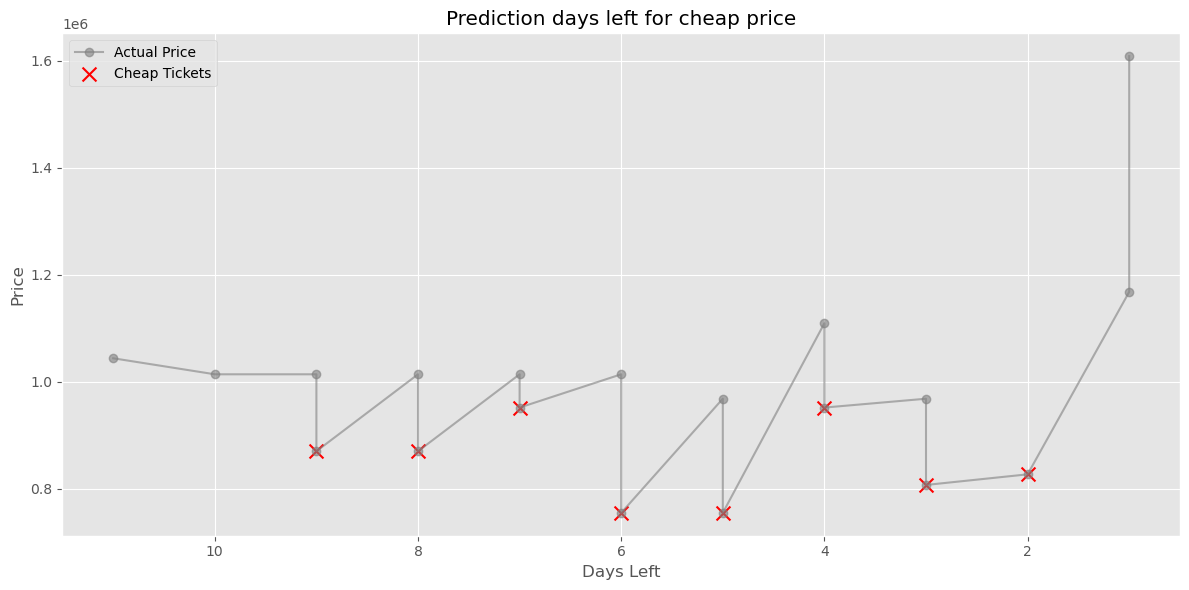

Bamboo Airways - Đà Nẵng (DAD)
Sân bay Đà Nẵng


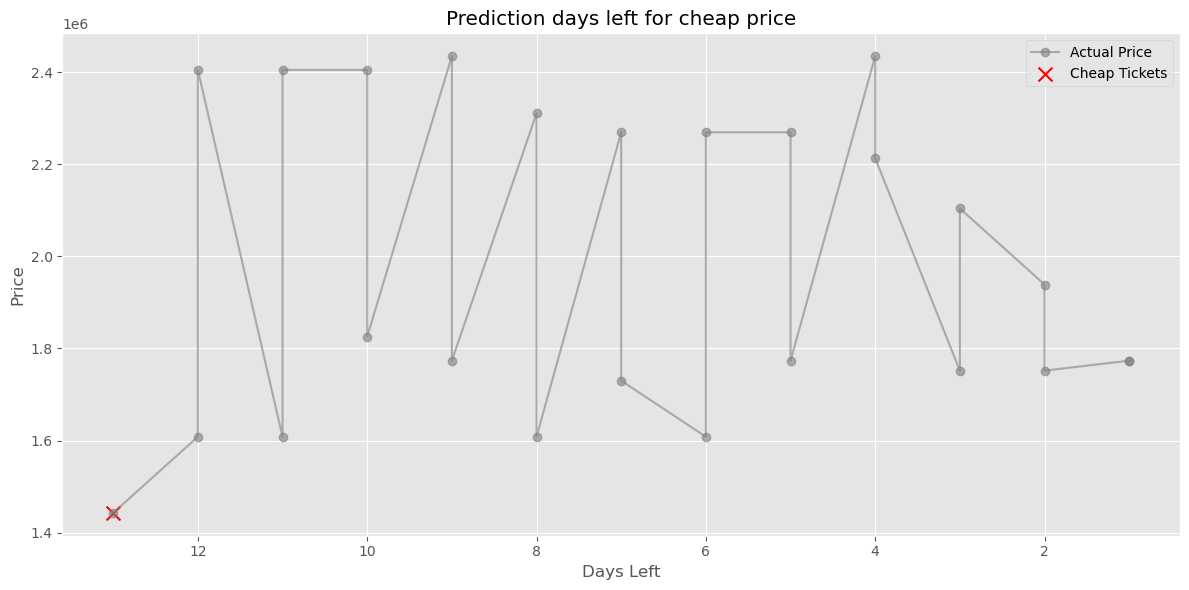

Bamboo Airways - Hà Nội (HAN)
Sân bay Nội Bài


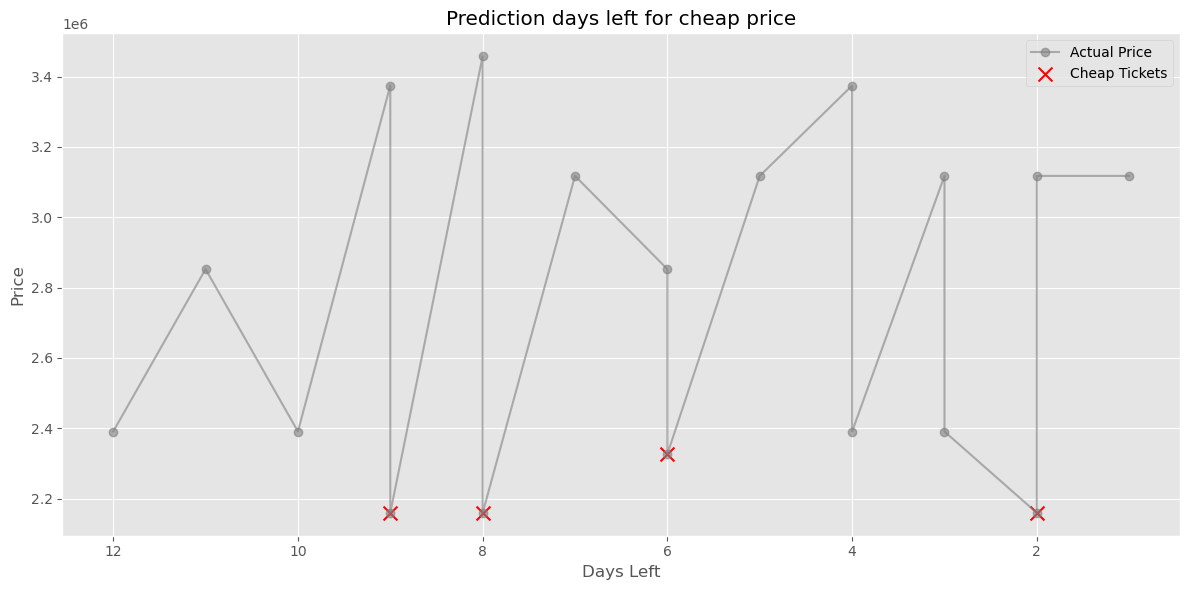

Bamboo Airways - Hải Phòng (HPH)
Sân bay quốc tế Cát Bi


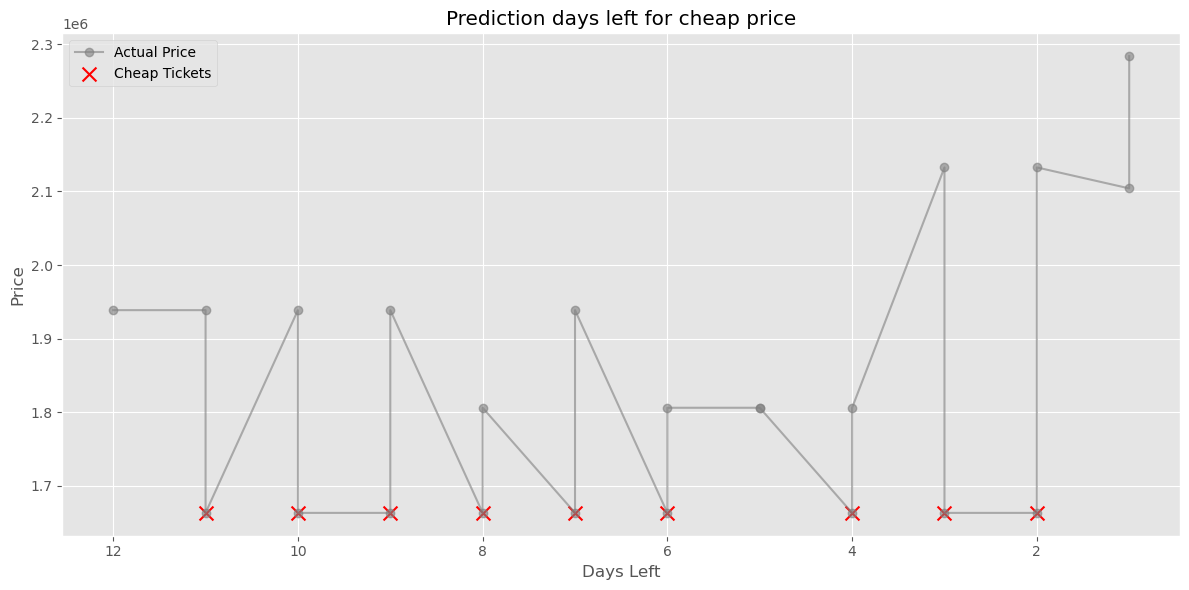

Bamboo Airways - Đà Lạt (DLI)
Sân bay Liên Khương


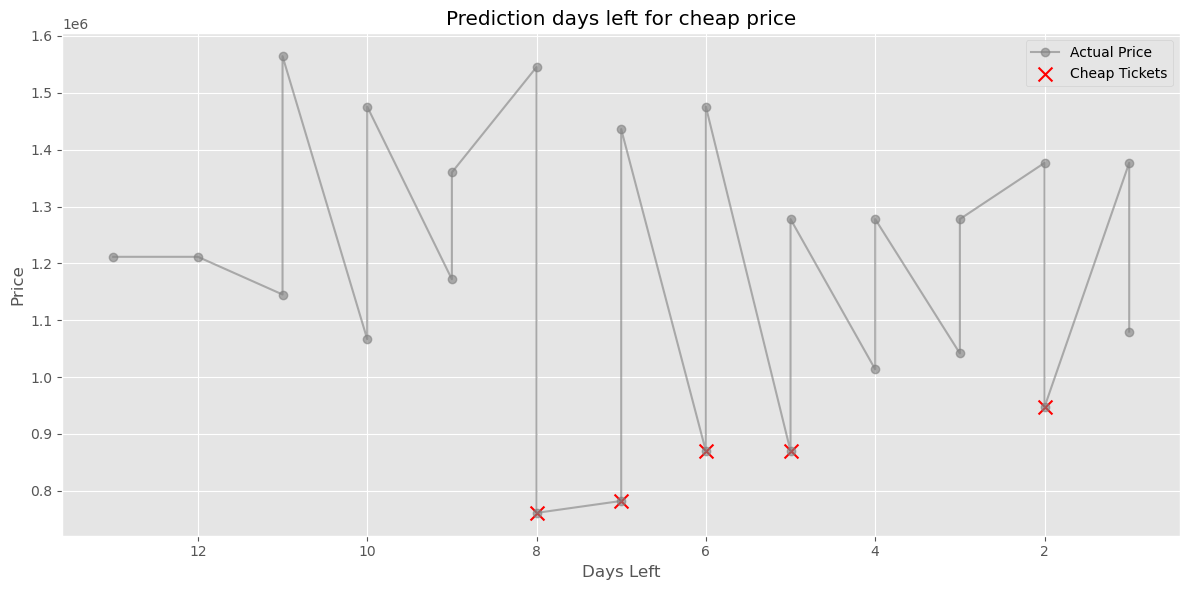

Vietjet Air - Phú Quốc (PQC)
Sân bay Phú Quốc


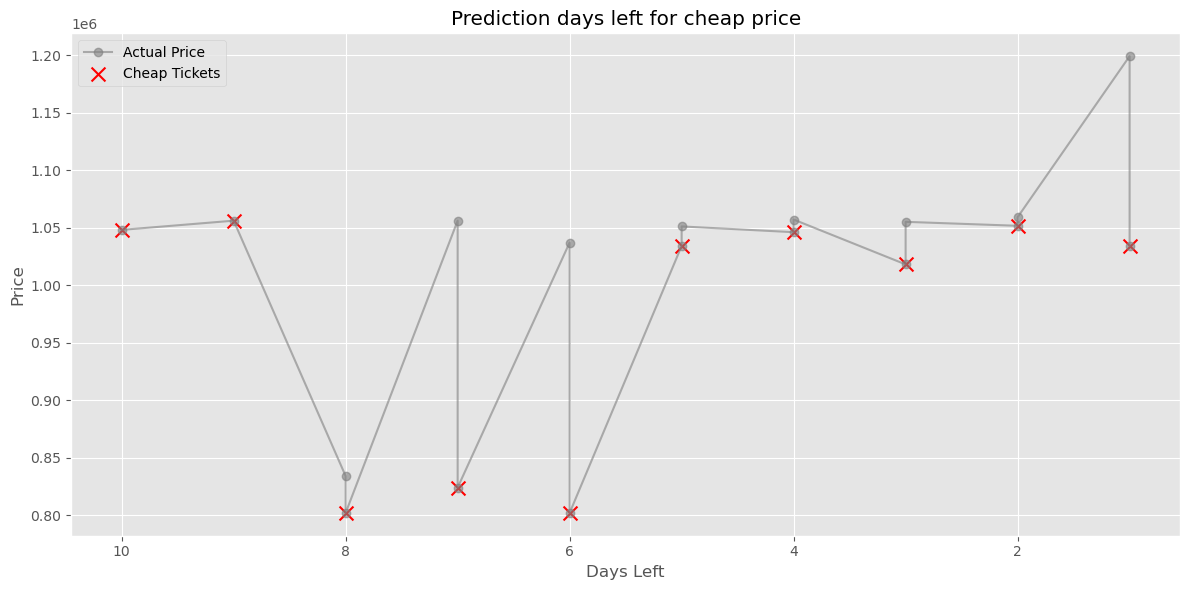

Vietjet Air - Đà Nẵng (DAD)
Sân bay Đà Nẵng


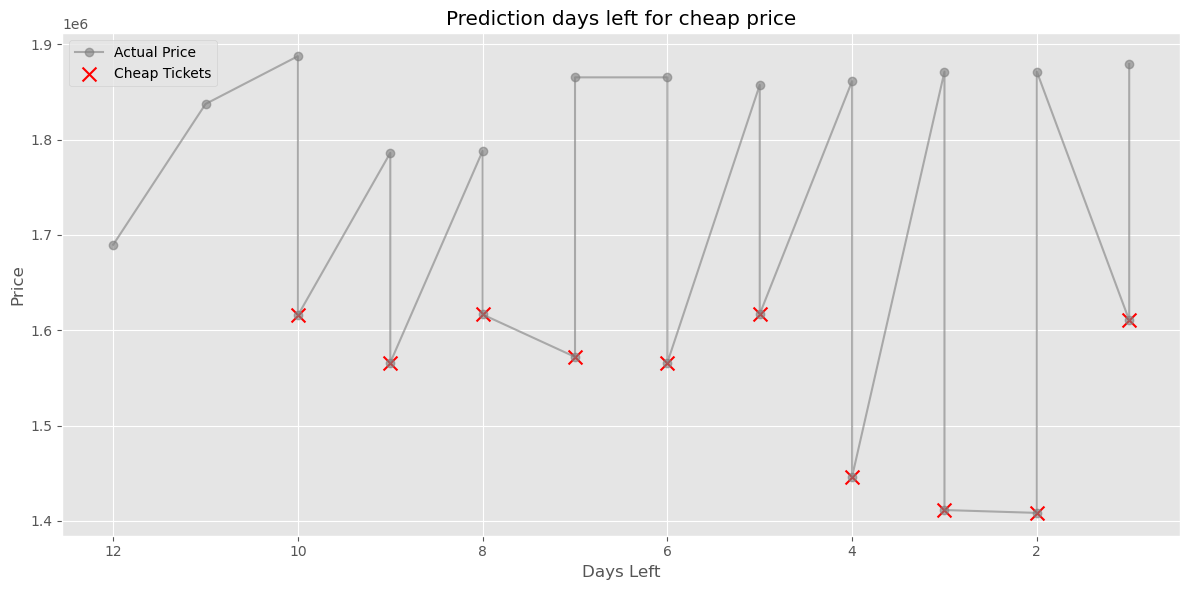

Vietjet Air - Hà Nội (HAN)
Sân bay Nội Bài


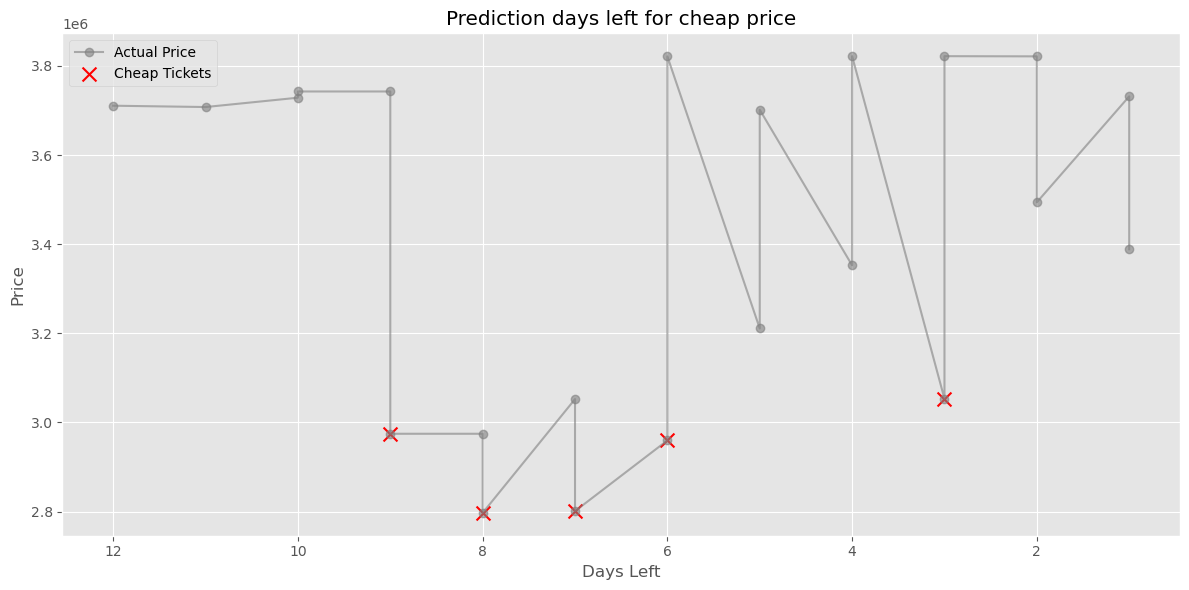

Vietjet Air - Hải Phòng (HPH)
Sân bay quốc tế Cát Bi


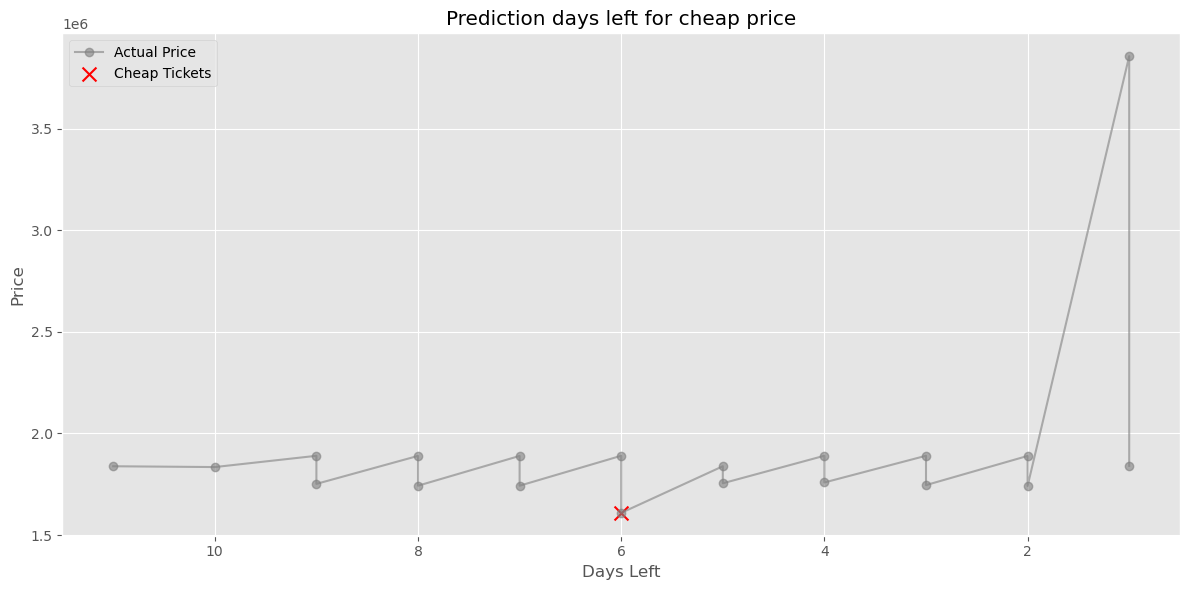

Vietjet Air - Đà Lạt (DLI)
Sân bay Liên Khương


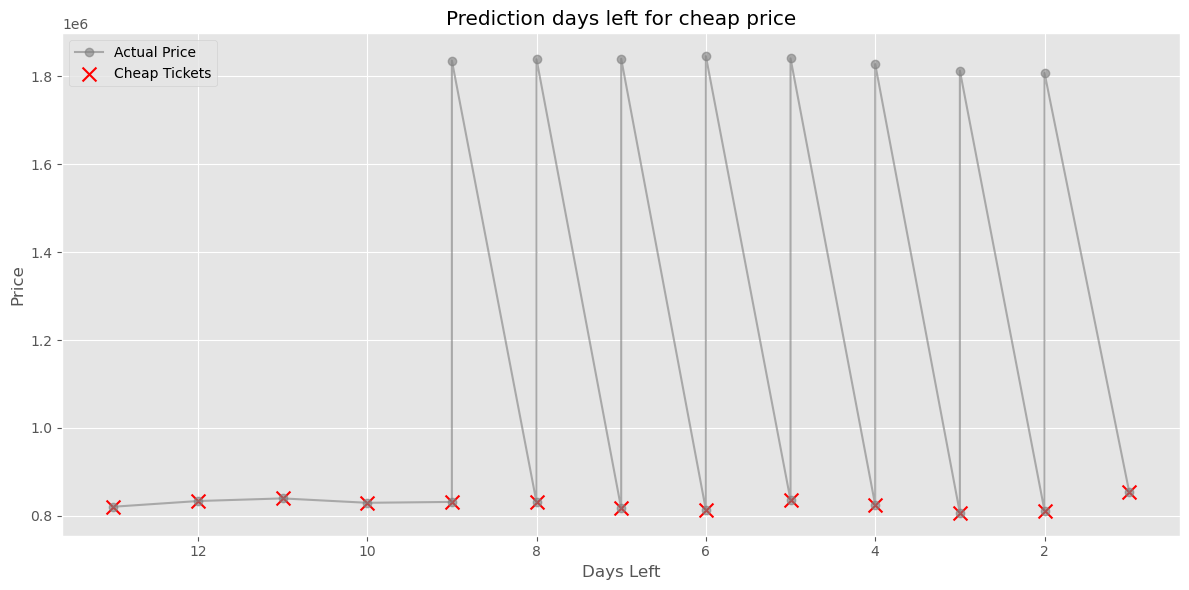

Vietjet Air - Nha Trang (CXR)
Sân bay Cam Ranh


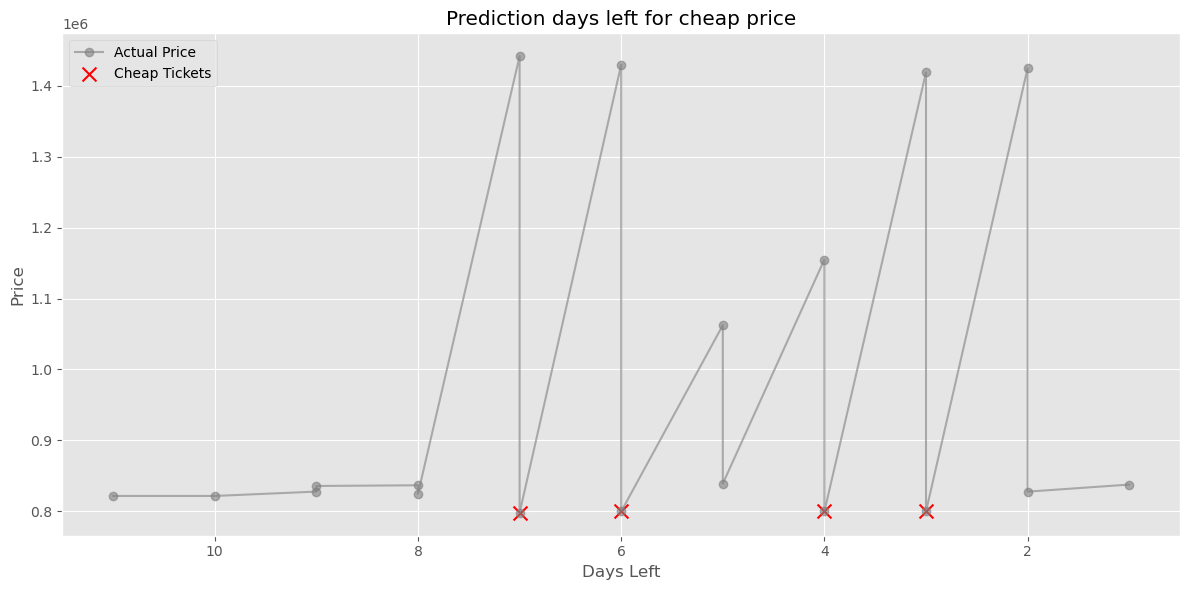

Vietnam Airlines - Phú Quốc (PQC)
Sân bay Phú Quốc


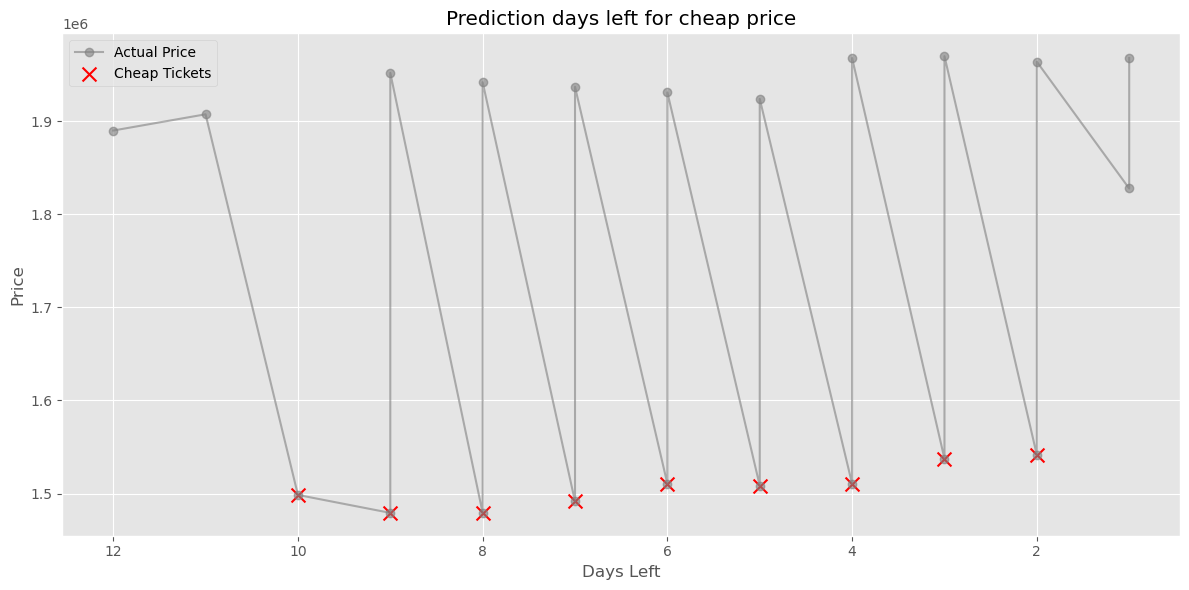

Vietnam Airlines - Đà Nẵng (DAD)
Sân bay Đà Nẵng


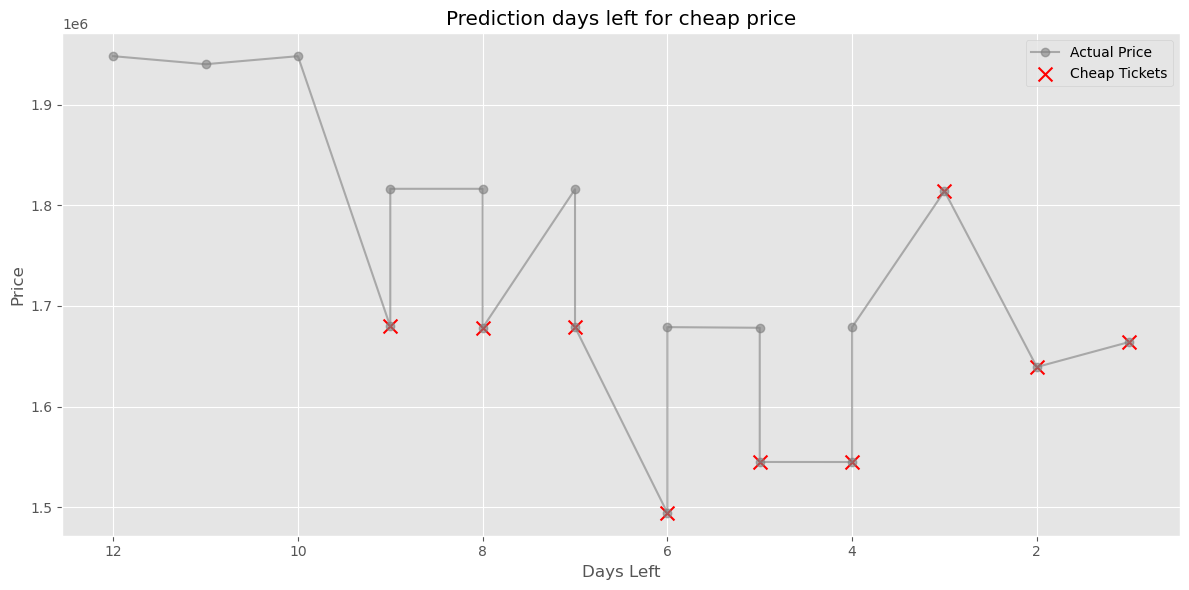

Vietnam Airlines - Hà Nội (HAN)
Sân bay Nội Bài


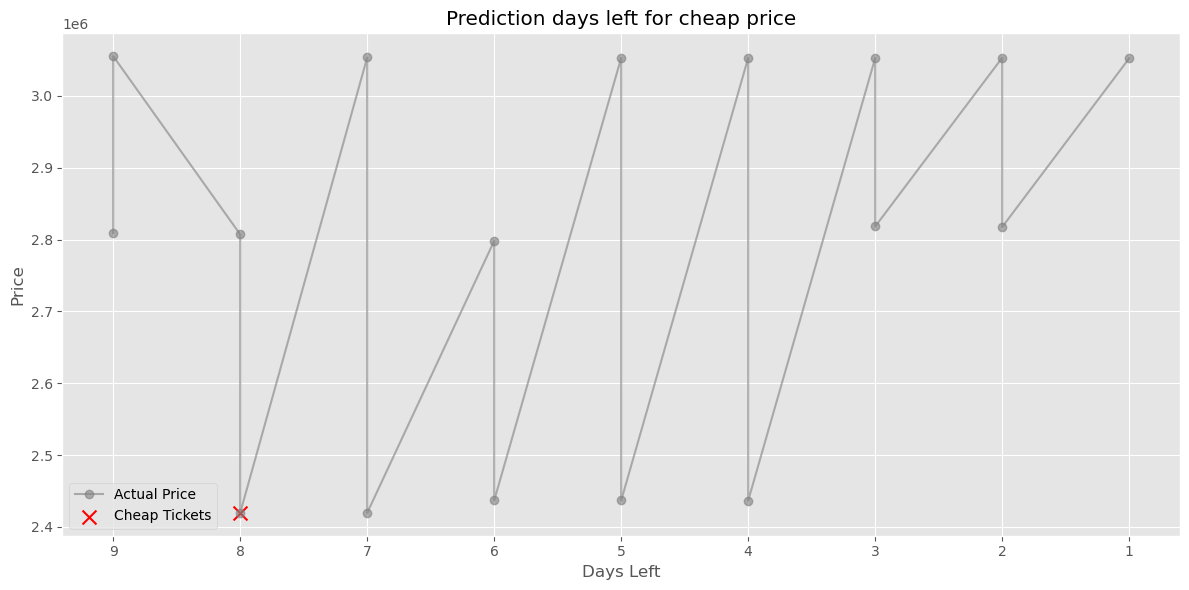

Vietnam Airlines - Hải Phòng (HPH)
Sân bay quốc tế Cát Bi


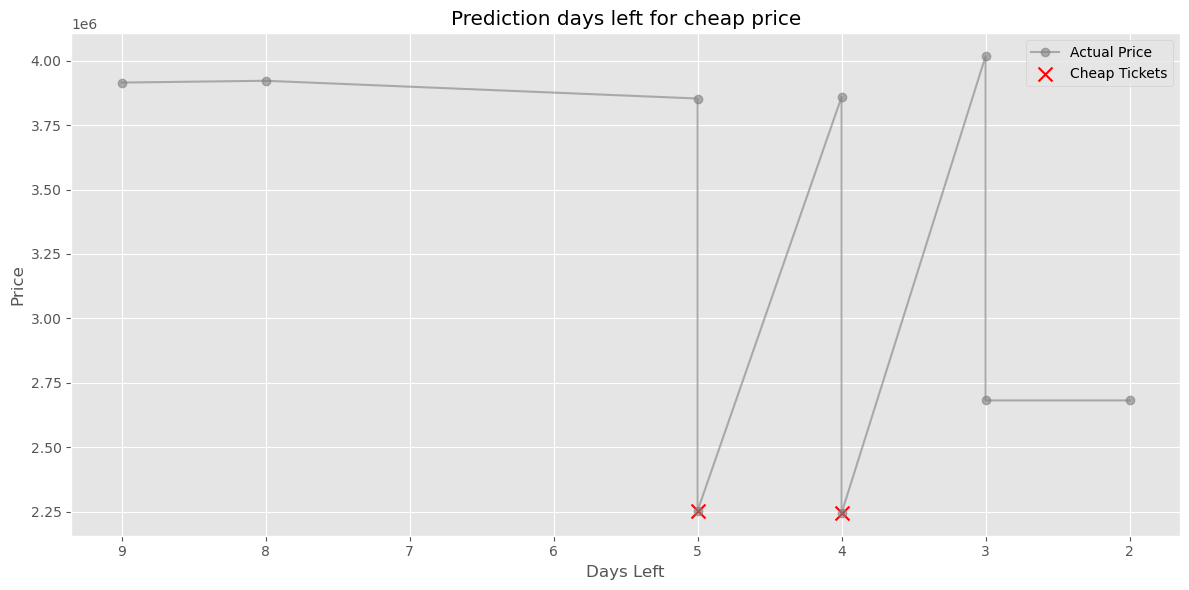

Vietnam Airlines - Đà Lạt (DLI)
Sân bay Liên Khương


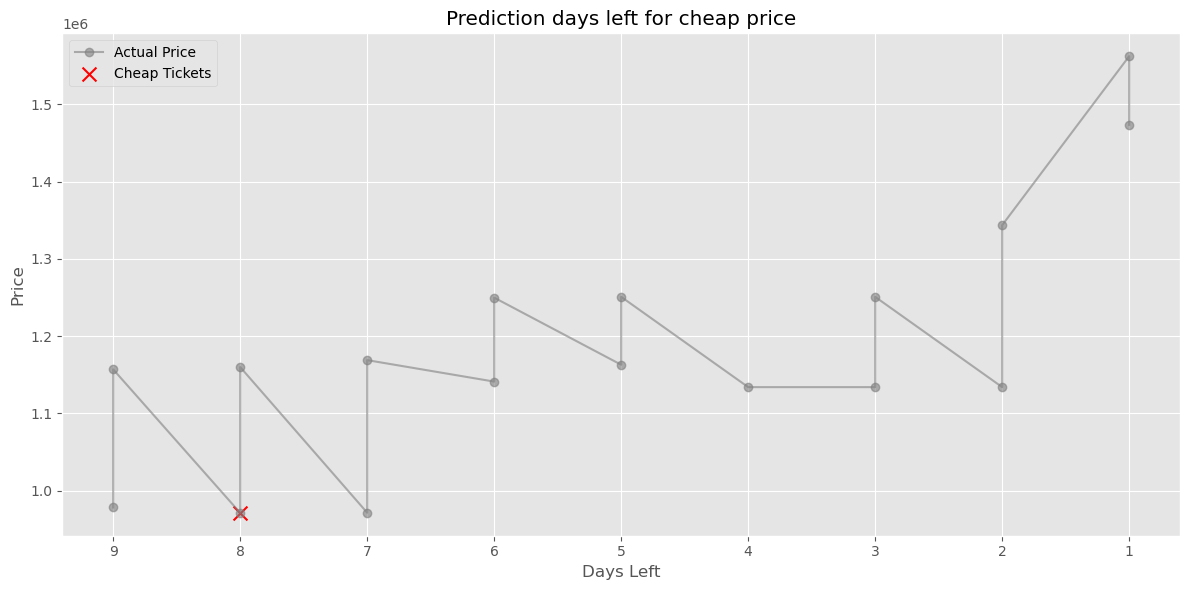

Vietnam Airlines - Nha Trang (CXR)
Sân bay Cam Ranh


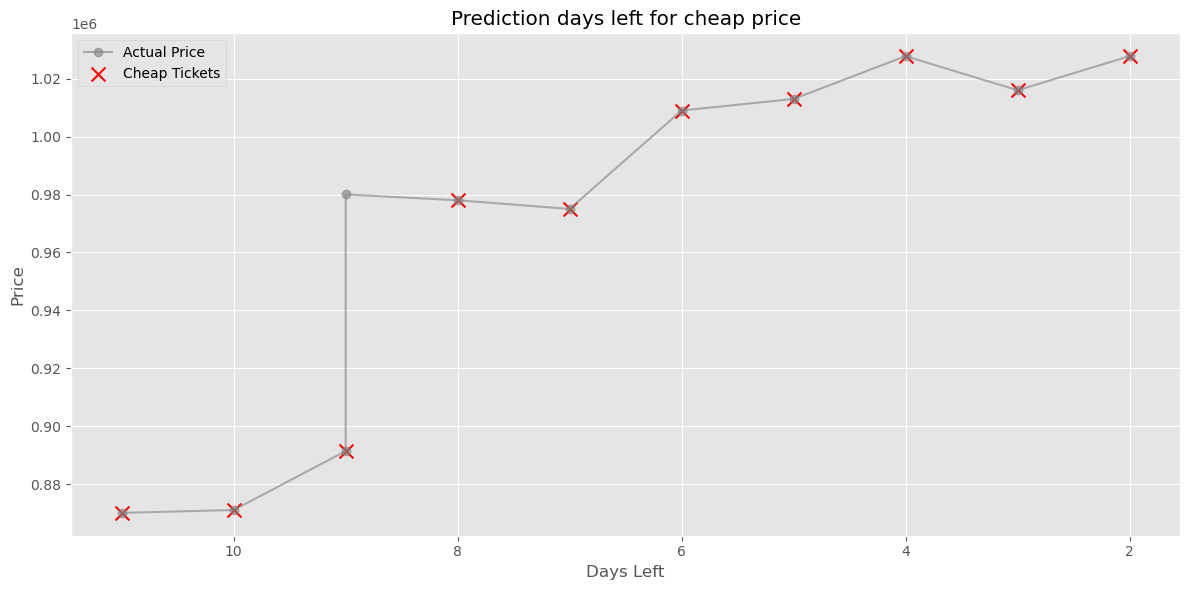

Vietravel - Phú Quốc (PQC)
Sân bay Phú Quốc


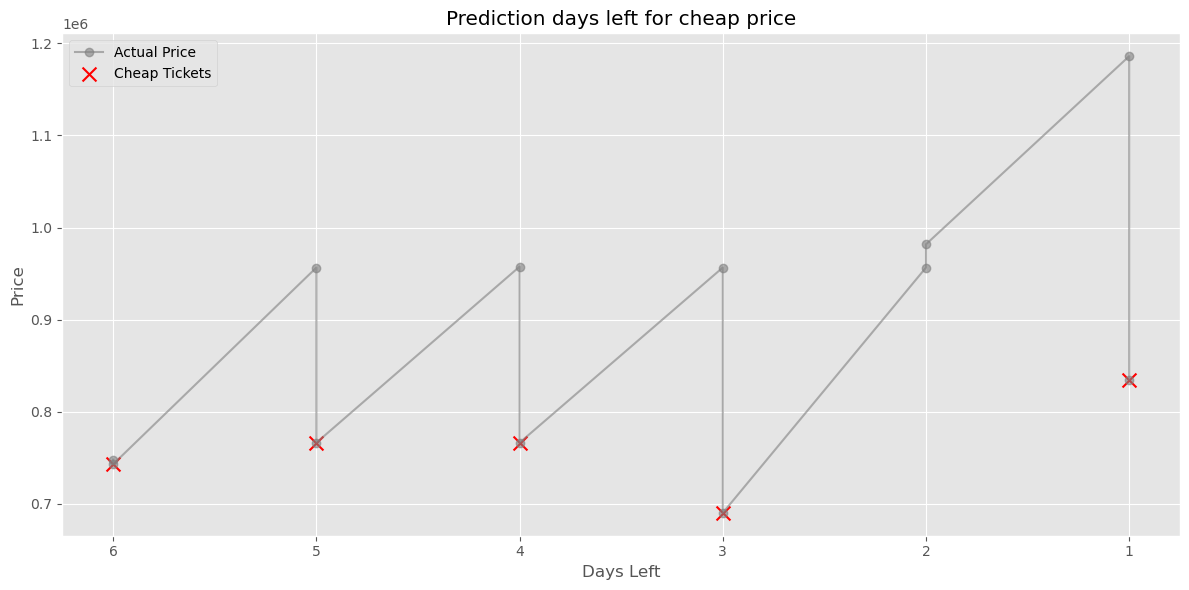

Vietravel - Đà Nẵng (DAD)
Sân bay Đà Nẵng


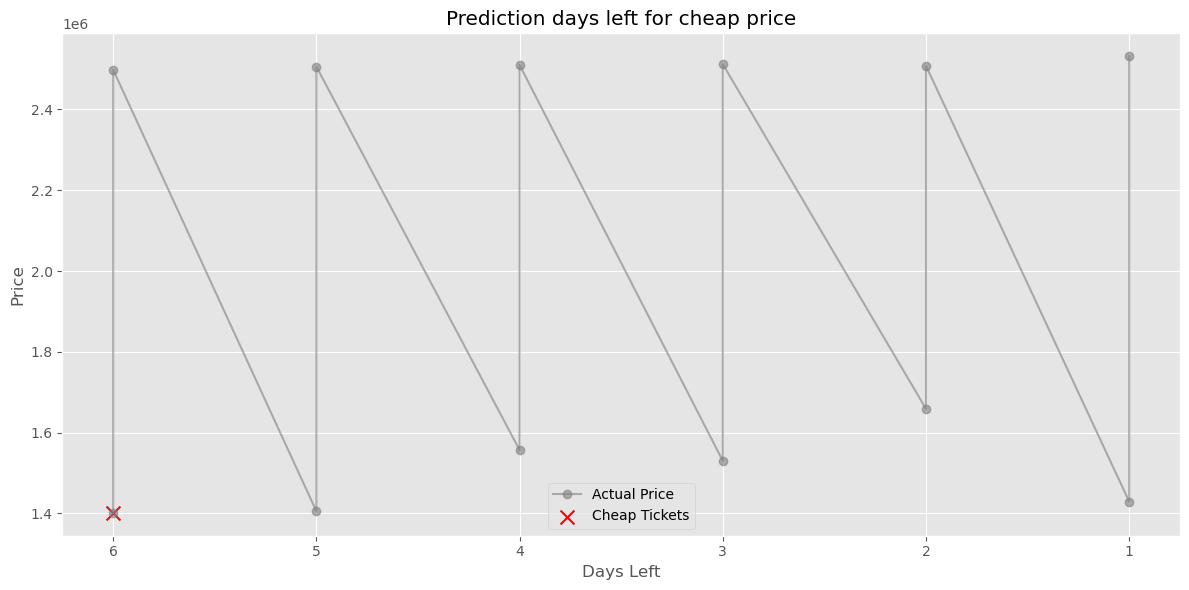

Vietravel - Hà Nội (HAN)
Sân bay Nội Bài


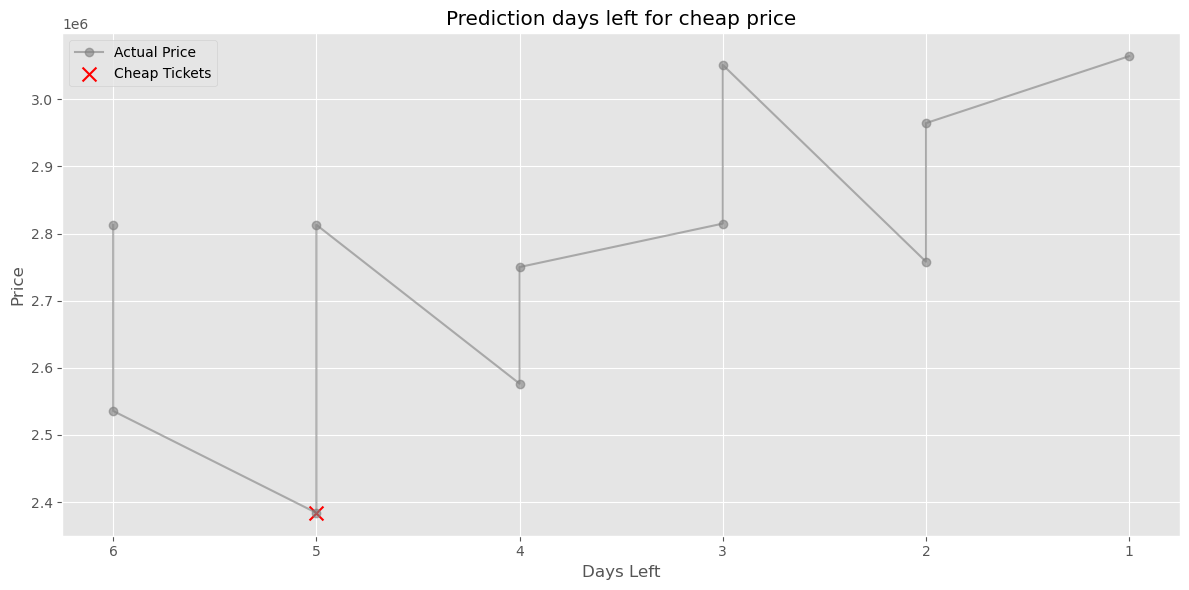

In [141]:
for des in Bamboo_predicted['destination'].unique():
    print(f'Bamboo Airways - {des}')
    plot_price_trend(Bamboo_predicted[Bamboo_predicted['destination'] == des])

for des in Vietjet_predicted['destination'].unique():
    print(f'Vietjet Air - {des}')
    plot_price_trend(Vietjet_predicted[Vietjet_predicted['destination'] == des])

for des in Vietnam_predicted['destination'].unique():
    print(f'Vietnam Airlines - {des}')
    plot_price_trend(Vietnam_predicted[Vietnam_predicted['destination'] == des])

for des in Vietravel_predicted['destination'].unique():
    print(f'Vietravel - {des}')
    plot_price_trend(Vietravel_predicted[Vietravel_predicted['destination'] == des])

In [142]:
Vietravel_predicted[Vietravel_predicted['destination'] == 'Đà Nẵng (DAD)\nSân bay Đà Nẵng']


,destination,trip_mins,is_holiday,days_left,start_hour_Afternoon,start_hour_EarlyMorning,start_hour_Evening,start_hour_LateNight,start_hour_Morning,end_hour_Afternoon,end_hour_EarlyMorning,end_hour_Evening,end_hour_LateNight,end_hour_Morning,hand_luggage_7,hand_luggage_10,hand_luggage_12,checked_baggage_0,checked_baggage_20,checked_baggage_23,Actual Price,Predicted Price,is_cheap,cheap_threshold
12,Đà Nẵng (DAD)\nSân bay Đà Nẵng,80,2,6,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,2497740,1.681984e+06,0,1.387334e+06
13,Đà Nẵng (DAD)\nSân bay Đà Nẵng,80,2,5,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,2505720,1.681984e+06,0,1.387334e+06
14,Đà Nẵng (DAD)\nSân bay Đà Nẵng,80,2,4,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,2509710,1.730179e+06,0,1.387334e+06
15,Đà Nẵng (DAD)\nSân bay Đà Nẵng,80,2,3,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,2511705,1.736430e+06,0,1.387334e+06
16,Đà Nẵng (DAD)\nSân bay Đà Nẵng,80,2,2,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,2507715,1.769330e+06,0,1.387334e+06
17,Đà Nẵng (DAD)\nSân bay Đà Nẵng,80,2,1,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,2531655,1.859515e+06,0,1.387334e+06
18,Đà Nẵng (DAD)\nSân bay Đà Nẵng,80,1,6,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,1401488,1.387334e+06,1,1.387334e+06
19,Đà Nẵng (DAD)\nSân bay Đà Nẵng,80,1,5,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,1405478,1.411401e+06,0,1.387334e+06
20,Đà Nẵng (DAD)\nSân bay Đà Nẵng,80,1,4,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,1556884,1.438434e+06,0,1.387334e+06
21,Đà Nẵng (DAD)\nSân bay Đà Nẵng,80,1,3,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,1530165,1.438882e+06,0,1.387334e+06


In [143]:
Vietnam_predicted[Vietnam_predicted['destination'] == 'Nha Trang (CXR)\nSân bay Cam Ranh'].describe()

,trip_mins,is_holiday,days_left,Actual Price,Predicted Price,is_cheap,cheap_threshold
count,11.0,11.000000,11.000000,1.100000e+01,1.100000e+01,11.000000,1.100000e+01
mean,65.0,1.727273,6.727273,9.690202e+05,1.057466e+06,0.909091,1.040935e+06
std,0.0,0.467099,2.969542,6.184743e+04,1.837541e+04,0.301511,0.000000e+00
min,65.0,1.000000,2.000000,8.701290e+05,1.040935e+06,0.000000,1.040935e+06
25%,65.0,1.500000,4.500000,9.332370e+05,1.050151e+06,1.000000,1.040935e+06
50%,65.0,2.000000,7.000000,9.800190e+05,1.050151e+06,1.000000,1.040935e+06
75%,65.0,2.000000,9.000000,1.014484e+06,1.053988e+06,1.000000,1.040935e+06
max,65.0,2.000000,11.000000,1.027746e+06,1.102101e+06,1.000000,1.040935e+06


In [144]:
Vietnam_predicted[Vietnam_predicted['destination'] == 'Nha Trang (CXR)\nSân bay Cam Ranh']

,destination,trip_mins,is_holiday,days_left,start_hour_Afternoon,start_hour_EarlyMorning,start_hour_Evening,start_hour_LateNight,start_hour_Morning,end_hour_Afternoon,end_hour_EarlyMorning,end_hour_Evening,end_hour_LateNight,end_hour_Morning,hand_luggage_7,hand_luggage_10,hand_luggage_12,checked_baggage_0,checked_baggage_20,checked_baggage_23,Actual Price,Predicted Price,is_cheap,cheap_threshold
82,Nha Trang (CXR)\nSân bay Cam Ranh,65,2,9,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,980019,1.050151e+06,0,1.040935e+06
83,Nha Trang (CXR)\nSân bay Cam Ranh,65,2,8,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,978021,1.050151e+06,1,1.040935e+06
84,Nha Trang (CXR)\nSân bay Cam Ranh,65,2,7,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,975024,1.050151e+06,1,1.040935e+06
85,Nha Trang (CXR)\nSân bay Cam Ranh,65,2,6,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,1008990,1.050151e+06,1,1.040935e+06
86,Nha Trang (CXR)\nSân bay Cam Ranh,65,2,5,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,1012986,1.050151e+06,1,1.040935e+06
87,Nha Trang (CXR)\nSân bay Cam Ranh,65,2,4,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,1027746,1.055997e+06,1,1.040935e+06
88,Nha Trang (CXR)\nSân bay Cam Ranh,65,2,3,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,1015983,1.083782e+06,1,1.040935e+06
89,Nha Trang (CXR)\nSân bay Cam Ranh,65,2,2,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,1027746,1.102101e+06,1,1.040935e+06
90,Nha Trang (CXR)\nSân bay Cam Ranh,65,1,11,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,870129,1.051980e+06,1,1.040935e+06
91,Nha Trang (CXR)\nSân bay Cam Ranh,65,1,10,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,871128,1.040935e+06,1,1.040935e+06
